#####git

In [ ]:
import os
from google.colab import userdata

# 1. Volta para a raiz e limpa tudo
%cd /content
!rm -rf /content/projeto

# 2. Configurações
!git config --global user.email "be.ctrindade@gmail.com"
!git config --global user.name "TrindadeBC"

# 3. Clone Direcionado (Clona diretamente a branch patch-1)
TOKEN = userdata.get('GITHUB_TOKEN')
REPO_URL = f"https://{TOKEN}@github.com/TrindadeBc/cd2-projeto-3.git"

# O segredo é o '-b patch-1' no final
!git clone {REPO_URL} /content/projeto -b patch-1

# 4. Entra na pasta
%cd /content/projeto

/content
Cloning into '/content/projeto'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 20 (delta 3), reused 5 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (20/20), 686.16 KiB | 6.35 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/projeto


In [137]:
# 1. Adiciona as mudanças no repositório DATASUS
!git add .

# 2. Executa o commit estruturado
!git commit -m "Refatoração da análise temporal e inclusão de métricas regionais (Nordeste)" \
            -m "- Correção do Índice de Sazonalidade Mensal para garantir valores entre 0-100%." \
            -m "- Implementação de lógica robusta (blindada) para cruzamento de dados temporais." \
            -m "- Inclusão de análise específica para as 9 capitais da região Nordeste." \
            -m "- Adição de mapeamento oficial do IBGE para nomes de Estados." \
            -m "- Refinação do filtro de ruído (mínimo de 10 casos) para evitar distorções estatísticas." \
            -m "- Padronização dos DataFrames (df_ml) para consistência no Machine Learning."

# 3. Envia para a sua branch de trabalho
!git push origin patch-1

On branch patch-1
Your branch is up to date with 'origin/patch-1'.

nothing to commit, working tree clean
Everything up-to-date


In [138]:
# 1. Adiciona as mudanças
!git add .

# 2. Registra a alteração com uma mensagem
!git commit -m "Implementação do modelo K-Means com k=3 e visualização via componentes principais (PCA)."

# 3. Envia para o GitHub (na branch main)
!git push origin patch-1

On branch patch-1
Your branch is up to date with 'origin/patch-1'.

nothing to commit, working tree clean
Everything up-to-date


#Baixar e extrair os dados
#(pode ser usada para dar reset no CSV)

In [83]:
import pandas as pd

# Baixa o arquivo zipado diretamente do servidor do Ministério da Saúde
!wget "https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/SINAN/Dengue/csv/DENGBR25.csv.zip" -O dengue_2025.zip

# Descompacta o arquivo na pasta 'dados_dengue'
!unzip dengue_2025.zip -d /content/dados_dengue

# Remove o arquivo zip para limpar o espaço em disco
!rm dengue_2025.zip

# Para recriar o RESETAR df sem precisar executar as celulas apenas de relatório que demoram de ser executadas.
df = pd.read_csv('/content/dados_dengue/DENGBR25.csv', sep=',', low_memory=False)


--2026-03-01 22:53:47--  https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/SINAN/Dengue/csv/DENGBR25.csv.zip
Resolving s3.sa-east-1.amazonaws.com (s3.sa-east-1.amazonaws.com)... 52.95.163.96, 3.5.232.4, 3.5.234.158, ...
Connecting to s3.sa-east-1.amazonaws.com (s3.sa-east-1.amazonaws.com)|52.95.163.96|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 34127288 (33M) [binary/octet-stream]
Saving to: ‘dengue_2025.zip’

dengue_2025.zip     100%[===================>]  32.55M  11.8MB/s    in 2.8s    

2026-03-01 22:53:50 (11.8 MB/s) - ‘dengue_2025.zip’ saved [34127288/34127288]

Archive:  dengue_2025.zip
replace /content/dados_dengue/DENGBR25.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/dados_dengue/DENGBR25.csv  


#Célula de Mapeamento e Diagnóstico Ampliado (Geral - Percentual) (Instâncias, NaN e Ignorados)

--- ESTATÍSTICAS DE VOLUME ---
Total de Instâncias (Linhas): 1655637
Total de Atributos (Colunas): 121

--- RELATÓRIO DE ATRIBUTOS REDUNDANTES (16 colunas) ---
Estes campos não possuem variância e devem ser removidos no pré-processamento.
  Atributo Valor Fixo
 ID_AGRAVO        A90
DOENCA_TRA        0.0
MANI_HEMOR        0.0
  EPISTAXE        0.0
   GENGIVO        0.0
     METRO        0.0
 PETEQUIAS        0.0
  HEMATURA        0.0
   SANGRAM        0.0
    LACO_N        0.0
PLASMATICO        0.0
 EVIDENCIA        0.0
PLAQ_MENOR        0.0
   CON_FHD        0.0
  COMPLICA        0.0
 MIGRADO_W        0.0


--- RANKING DAS VARIÁVEIS POR AUSÊNCIA (%) ---
                                    Descricao  Total_Ausente_Perc
45           Data Coleta Chikungunya (Soro 2)           99.999698
46                     Data Coleta Exame PRNT           99.980189
44           Data Coleta Chikungunya (Soro 1)           99.930540
74                              Data do Óbito           99.852323
101     

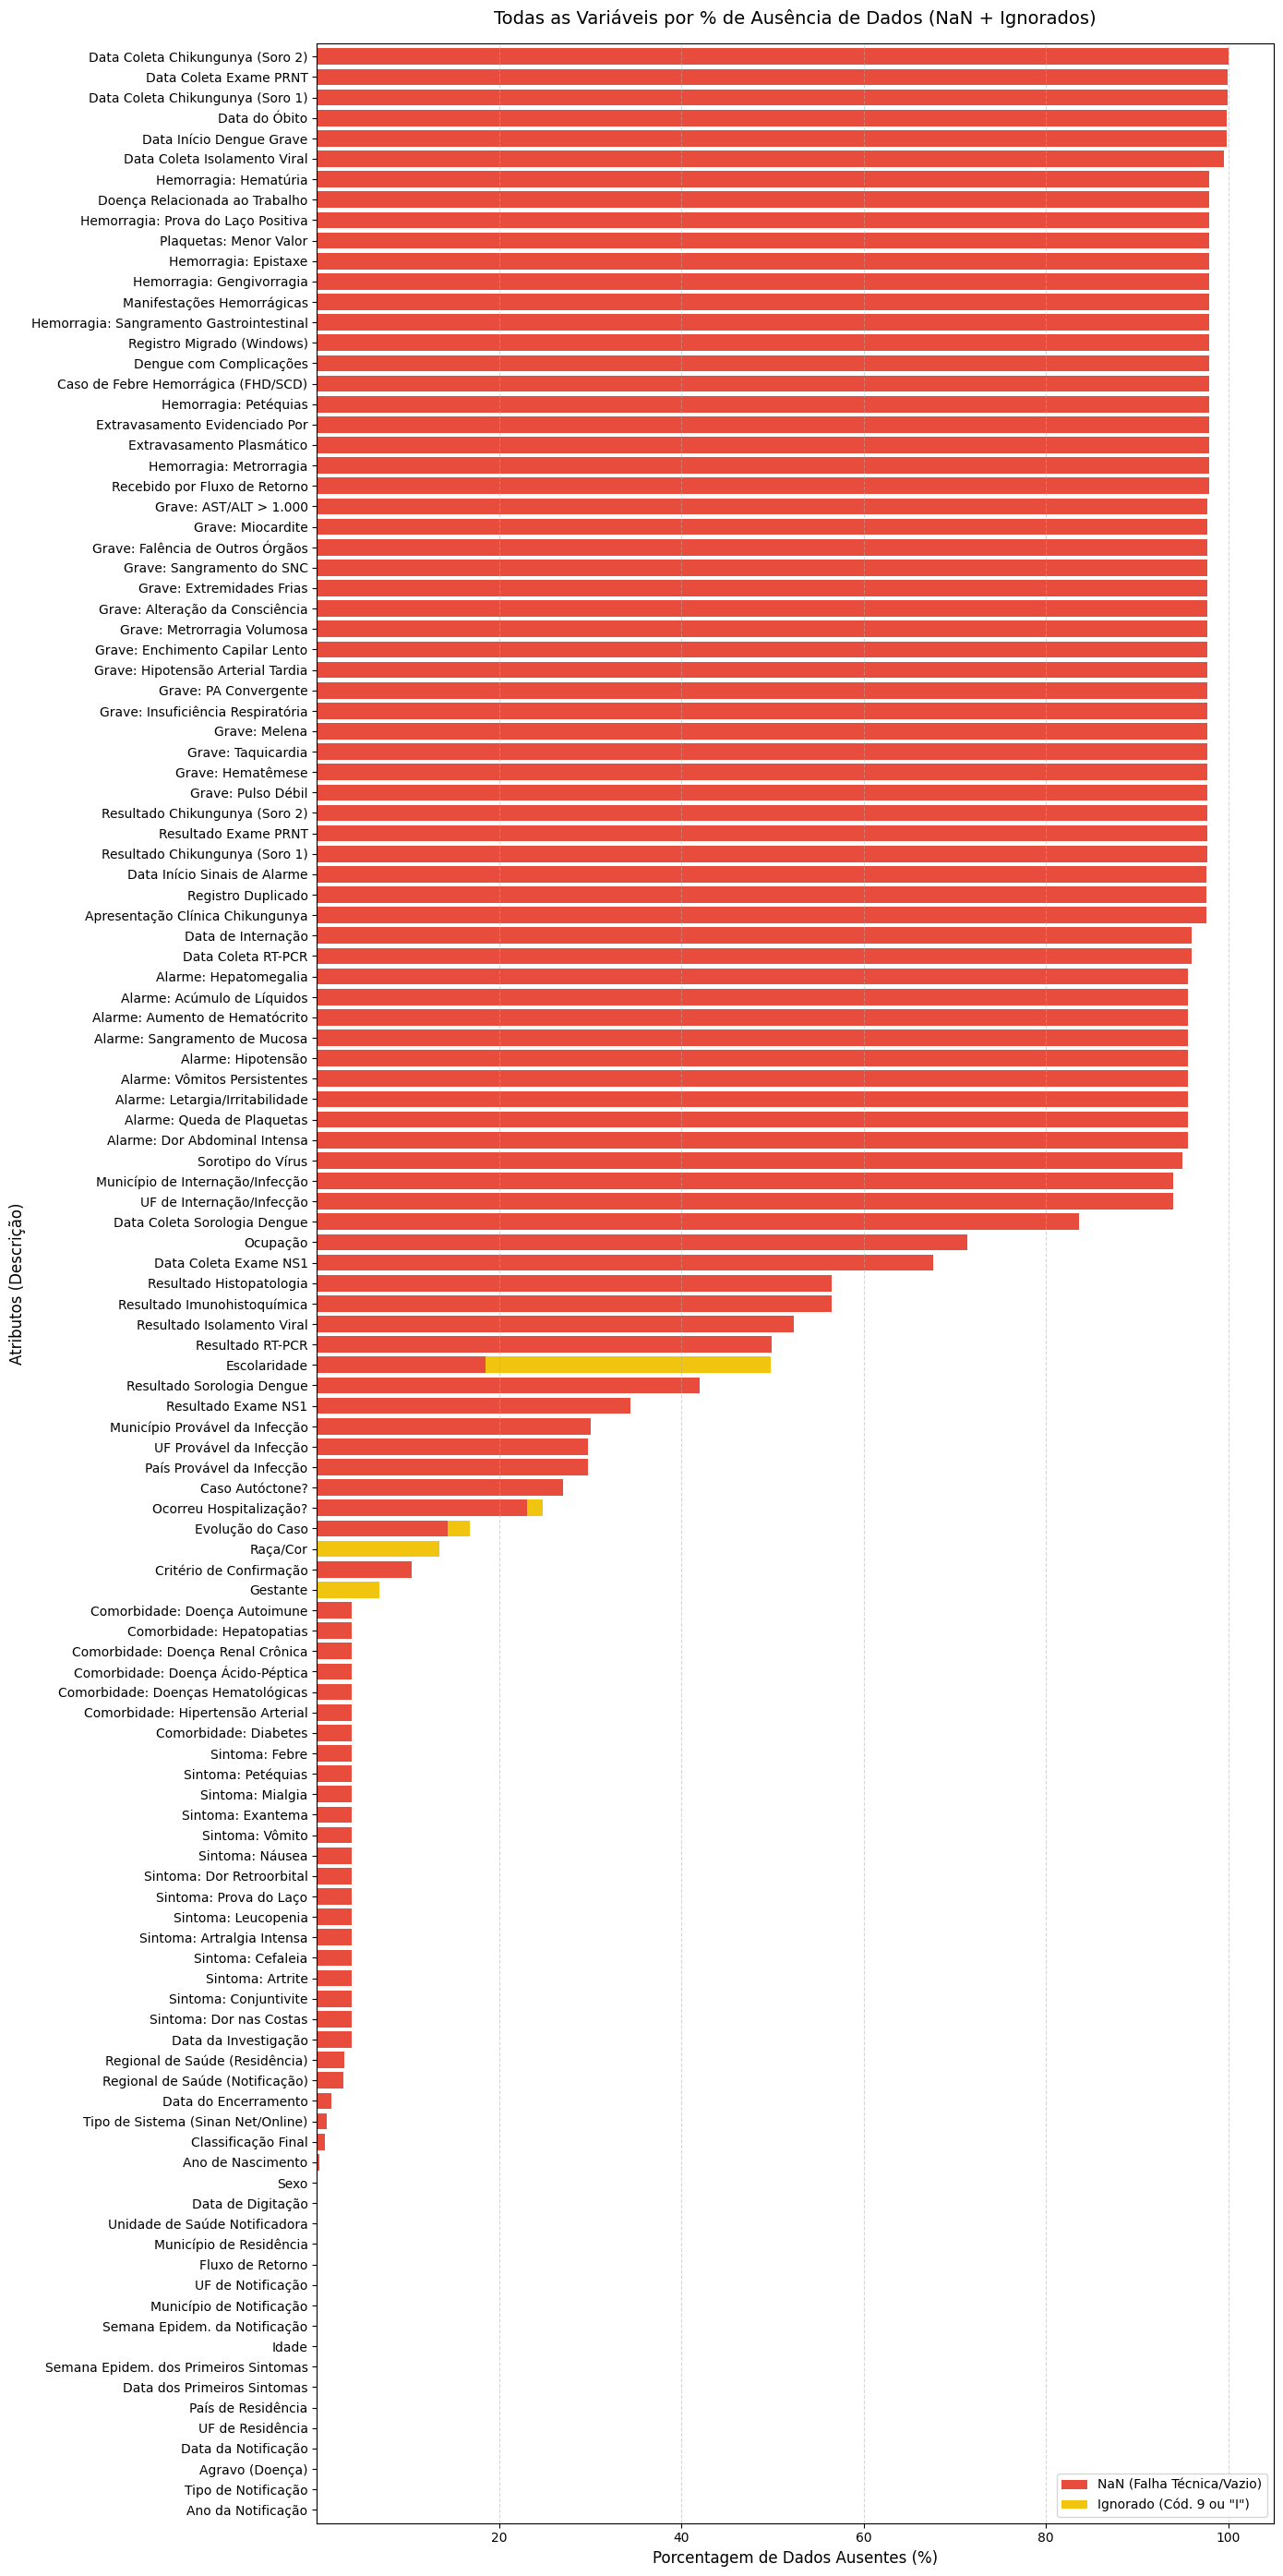

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==============================================================================
# 1. CARREGAMENTO DOS DADOS
# ==============================================================================
df = pd.read_csv('/content/dados_dengue/DENGBR25.csv', sep=',', low_memory=False)

# ==============================================================================
# 2. ESTATÍSTICAS DE VOLUME E REDUNDÂNCIA
# ==============================================================================
n_linhas, n_colunas = df.shape
print(f"--- ESTATÍSTICAS DE VOLUME ---")
print(f"Total de Instâncias (Linhas): {n_linhas}")
print(f"Total de Atributos (Colunas): {n_colunas}\n")

# Correção: Removemos o dropna=False para que colunas com 1 único valor + NaNs sejam pegas
colunas_constantes = [col for col in df.columns if df[col].nunique() == 1]

# Monta o relatório pegando o valor real (ignorando os NaNs)
relatorio_constantes = []
for col in colunas_constantes:
    valor_unico = df[col].dropna().unique()[0] if not df[col].dropna().empty else np.nan
    relatorio_constantes.append({'Atributo': col, 'Valor Fixo': valor_unico})

print(f"--- RELATÓRIO DE ATRIBUTOS REDUNDANTES ({len(colunas_constantes)} colunas) ---")
print("Estes campos não possuem variância e devem ser removidos no pré-processamento.")
print(pd.DataFrame(relatorio_constantes).to_string(index=False))
print("\n")

# ==============================================================================
# 3. DICIONÁRIO DE TRADUÇÃO COMPLETO (SINAN DAENT)
# ==============================================================================
map_nomes_colunas = {
    'TP_NOT': 'Tipo de Notificação', 'ID_AGRAVO': 'Agravo (Doença)', 'DT_NOTIFIC': 'Data da Notificação',
    'SEM_NOT': 'Semana Epidem. da Notificação', 'NU_ANO': 'Ano da Notificação', 'SG_UF_NOT': 'UF de Notificação',
    'ID_MUNICIP': 'Município de Notificação', 'ID_REGIONA': 'Regional de Saúde (Notificação)',
    'ID_UNIDADE': 'Unidade de Saúde Notificadora', 'DT_SIN_PRI': 'Data dos Primeiros Sintomas',
    'SEM_PRI': 'Semana Epidem. dos Primeiros Sintomas', 'ANO_NASC': 'Ano de Nascimento', 'NU_IDADE_N': 'Idade',
    'CS_SEXO': 'Sexo', 'CS_GESTANT': 'Gestante', 'CS_RACA': 'Raça/Cor', 'CS_ESCOL_N': 'Escolaridade',
    'SG_UF': 'UF de Residência', 'ID_MN_RESI': 'Município de Residência', 'ID_RG_RESI': 'Regional de Saúde (Residência)',
    'ID_PAIS': 'País de Residência', 'DT_INVEST': 'Data da Investigação', 'ID_OCUPA_N': 'Ocupação',
    'FEBRE': 'Sintoma: Febre', 'MIALGIA': 'Sintoma: Mialgia', 'CEFALEIA': 'Sintoma: Cefaleia',
    'EXANTEMA': 'Sintoma: Exantema', 'VOMITO': 'Sintoma: Vômito', 'NAUSEA': 'Sintoma: Náusea',
    'DOR_COSTAS': 'Sintoma: Dor nas Costas', 'CONJUNTVIT': 'Sintoma: Conjuntivite', 'ARTRITE': 'Sintoma: Artrite',
    'ARTRALGIA': 'Sintoma: Artralgia Intensa', 'PETEQUIA_N': 'Sintoma: Petéquias', 'LEUCOPENIA': 'Sintoma: Leucopenia',
    'LACO': 'Sintoma: Prova do Laço', 'DOR_RETRO': 'Sintoma: Dor Retroorbital', 'DIABETES': 'Comorbidade: Diabetes',
    'HEMATOLOG': 'Comorbidade: Doenças Hematológicas', 'HEPATOPAT': 'Comorbidade: Hepatopatias',
    'RENAL': 'Comorbidade: Doença Renal Crônica', 'HIPERTENSA': 'Comorbidade: Hipertensão Arterial',
    'ACIDO_PEPT': 'Comorbidade: Doença Ácido-Péptica', 'AUTO_IMUNE': 'Comorbidade: Doença Autoimune',
    'DT_CHIK_S1': 'Data Coleta Chikungunya (Soro 1)', 'DT_CHIK_S2': 'Data Coleta Chikungunya (Soro 2)',
    'DT_PRNT': 'Data Coleta Exame PRNT', 'RES_CHIKS1': 'Resultado Chikungunya (Soro 1)',
    'RES_CHIKS2': 'Resultado Chikungunya (Soro 2)', 'RESUL_PRNT': 'Resultado Exame PRNT',
    'DT_SORO': 'Data Coleta Sorologia Dengue', 'RESUL_SORO': 'Resultado Sorologia Dengue',
    'DT_NS1': 'Data Coleta Exame NS1', 'RESUL_NS1': 'Resultado Exame NS1', 'DT_VIRAL': 'Data Coleta Isolamento Viral',
    'RESUL_VI_N': 'Resultado Isolamento Viral', 'DT_PCR': 'Data Coleta RT-PCR', 'RESUL_PCR_': 'Resultado RT-PCR',
    'SOROTIPO': 'Sorotipo do Vírus', 'HISTOPA_N': 'Resultado Histopatologia', 'IMUNOH_N': 'Resultado Imunohistoquímica',
    'HOSPITALIZ': 'Ocorreu Hospitalização?', 'DT_INTERNA': 'Data de Internação', 'UF': 'UF de Internação/Infecção',
    'MUNICIPIO': 'Município de Internação/Infecção', 'TPAUTOCTO': 'Caso Autóctone?', 'COUFINF': 'UF Provável da Infecção',
    'COPAISINF': 'País Provável da Infecção', 'COMUNINF': 'Município Provável da Infecção', 'CLASSI_FIN': 'Classificação Final',
    'CRITERIO': 'Critério de Confirmação', 'DOENCA_TRA': 'Doença Relacionada ao Trabalho',
    'CLINC_CHIK': 'Apresentação Clínica Chikungunya', 'EVOLUCAO': 'Evolução do Caso', 'DT_OBITO': 'Data do Óbito',
    'DT_ENCERRA': 'Data do Encerramento', 'ALRM_HIPOT': 'Alarme: Hipotensão', 'ALRM_PLAQ': 'Alarme: Queda de Plaquetas',
    'ALRM_VOM': 'Alarme: Vômitos Persistentes', 'ALRM_SANG': 'Alarme: Sangramento de Mucosa',
    'ALRM_HEMAT': 'Alarme: Aumento de Hematócrito', 'ALRM_ABDOM': 'Alarme: Dor Abdominal Intensa',
    'ALRM_LETAR': 'Alarme: Letargia/Irritabilidade', 'ALRM_HEPAT': 'Alarme: Hepatomegalia',
    'ALRM_LIQ': 'Alarme: Acúmulo de Líquidos', 'DT_ALRM': 'Data Início Sinais de Alarme',
    'GRAV_PULSO': 'Grave: Pulso Débil', 'GRAV_CONV': 'Grave: PA Convergente', 'GRAV_ENCH': 'Grave: Enchimento Capilar Lento',
    'GRAV_INSUF': 'Grave: Insuficiência Respiratória', 'GRAV_TAQUI': 'Grave: Taquicardia',
    'GRAV_EXTRE': 'Grave: Extremidades Frias', 'GRAV_HIPOT': 'Grave: Hipotensão Arterial Tardia',
    'GRAV_HEMAT': 'Grave: Hematêmese', 'GRAV_MELEN': 'Grave: Melena', 'GRAV_METRO': 'Grave: Metrorragia Volumosa',
    'GRAV_SANG': 'Grave: Sangramento do SNC', 'GRAV_AST': 'Grave: AST/ALT > 1.000', 'GRAV_MIOC': 'Grave: Miocardite',
    'GRAV_CONSC': 'Grave: Alteração da Consciência', 'GRAV_ORGAO': 'Grave: Falência de Outros Órgãos',
    'DT_GRAV': 'Data Início Dengue Grave', 'MANI_HEMOR': 'Manifestações Hemorrágicas', 'EPISTAXE': 'Hemorragia: Epistaxe',
    'GENGIVO': 'Hemorragia: Gengivorragia', 'METRO': 'Hemorragia: Metrorragia', 'PETEQUIAS': 'Hemorragia: Petéquias',
    'HEMATURA': 'Hemorragia: Hematúria', 'SANGRAM': 'Hemorragia: Sangramento Gastrointestinal',
    'LACO_N': 'Hemorragia: Prova do Laço Positiva', 'PLASMATICO': 'Extravasamento Plasmático',
    'EVIDENCIA': 'Extravasamento Evidenciado Por', 'PLAQ_MENOR': 'Plaquetas: Menor Valor',
    'CON_FHD': 'Caso de Febre Hemorrágica (FHD/SCD)', 'COMPLICA': 'Dengue com Complicações',
    'TP_SISTEMA': 'Tipo de Sistema (Sinan Net/Online)', 'NDUPLIC_N': 'Registro Duplicado',
    'DT_DIGITA': 'Data de Digitação', 'CS_FLXRET': 'Fluxo de Retorno', 'FLXRECEBI': 'Recebido por Fluxo de Retorno',
    'MIGRADO_W': 'Registro Migrado (Windows)'
}

# ==============================================================================
# 4. DIAGNÓSTICO DE QUALIDADE OTIMIZADO E VELOZ
# ==============================================================================
valores_ignorados = [9, 9.0, '9', 99, 99.0, '99', 999, 999.0, '999', 'I']

dados_qualidade = []
for col in df.columns:
    nan_count = df[col].isna().sum()
    ign_count = df[col].isin(valores_ignorados).sum()

    nan_perc = (nan_count / n_linhas) * 100
    ign_perc = (ign_count / n_linhas) * 100

    dados_qualidade.append({
        'Descricao': map_nomes_colunas.get(col, col),
        'NaN_Perc': nan_perc,
        'Ignorado_Perc': ign_perc,
        'Total_Ausente_Perc': nan_perc + ign_perc
    })

df_qualidade = pd.DataFrame(dados_qualidade)
todas_faltantes = df_qualidade.sort_values(by='Total_Ausente_Perc', ascending=False)

print(f"--- RANKING DAS VARIÁVEIS POR AUSÊNCIA (%) ---")
pd.set_option('display.max_rows', 130)
print(todas_faltantes[['Descricao', 'Total_Ausente_Perc']])

# ==============================================================================
# 5. PLOT DE VISUALIZAÇÃO GERAL
# ==============================================================================
plt.figure(figsize=(14, 28))
todas_faltantes.set_index('Descricao')[['NaN_Perc', 'Ignorado_Perc']].plot(
    kind='barh',
    stacked=True,
    color=['#e74c3c', '#f1c40f'],
    ax=plt.gca(),
    width=0.8
)

plt.title('Todas as Variáveis por % de Ausência de Dados (NaN + Ignorados)', fontsize=14, pad=15)
plt.xlabel('Porcentagem de Dados Ausentes (%)', fontsize=12)
plt.ylabel('Atributos (Descrição)', fontsize=12)
plt.legend(['NaN (Falha Técnica/Vazio)', 'Ignorado (Cód. 9 ou "I")'], loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#Verificação de ausentes e ignorados específicos'
#Análise Focada de Ausência nos 10 Atributos Geográficos/Administrativos

--- RELATÓRIO DE QUALIDADE: VARIÁVEIS GEOGRÁFICAS E NOTIFICAÇÃO ---
                                    Atributo   NaN (%)  Ignorado / Zerado (%)  Total_Ausente (%)
   Município Provável da Infecção (COMUNINF) 30.033878               2.089951          32.123829
           UF Provável da Infecção (COUFINF) 29.790105               2.089951          31.880056
     Caso Autóctone? (TPAUTOCTO) (TPAUTOCTO) 27.050434               2.215763          29.266198
 Regional de Saúde (Residência) (ID_RG_RESI)  2.977827               0.001329           2.979155
Regional de Saúde (Notificação) (ID_REGIONA)  2.943701               0.000000           2.943701
  Unidade de Saúde Notificadora (ID_UNIDADE)  0.009724               0.000000           0.009724
        Município de Residência (ID_MN_RESI)  0.000423               0.000000           0.000423
                    UF de Residência (SG_UF)  0.000000               0.000000           0.000000
               UF da Notificação (SG_UF_NOT)  0.000000     

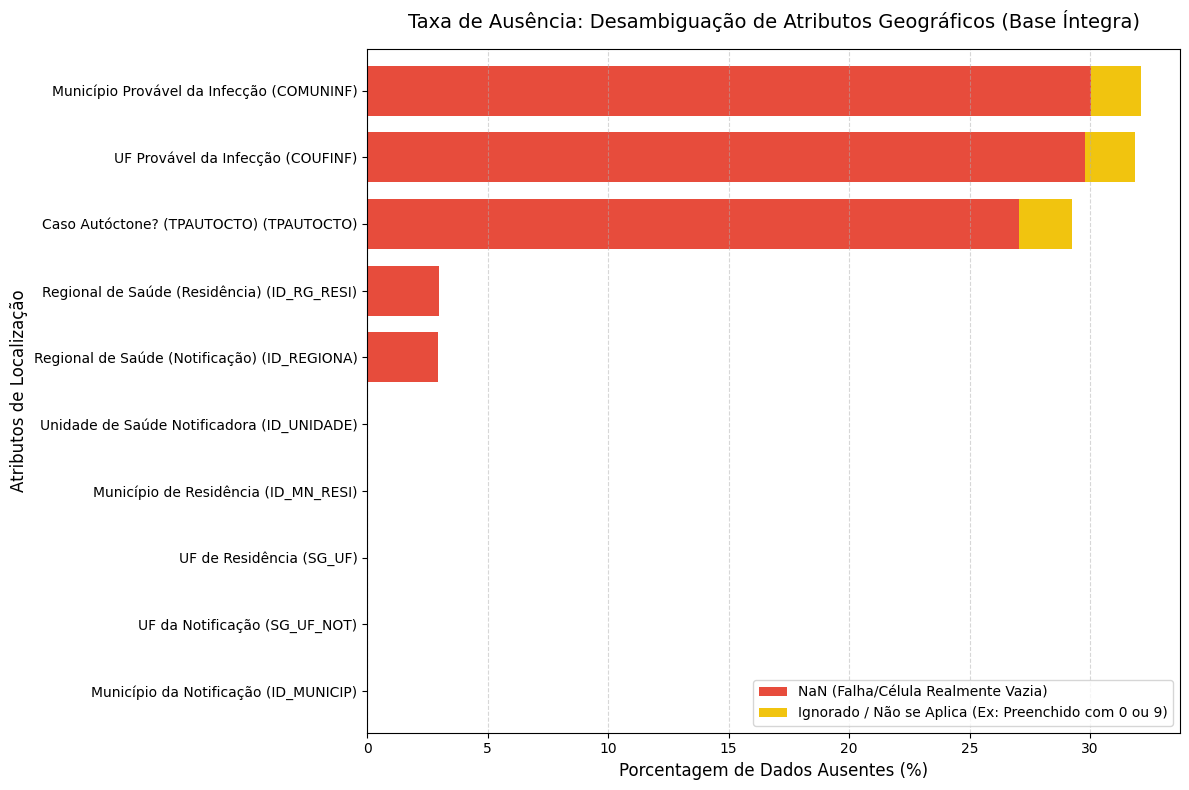

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Definindo os 10 atributos exatos solicitados
colunas_geo = [
    'ID_MN_RESI', 'SG_UF', 'ID_RG_RESI',
    'ID_MUNICIP', 'SG_UF_NOT', 'ID_REGIONA', 'ID_UNIDADE',
    'COMUNINF', 'COUFINF', 'TPAUTOCTO'
]

# Dicionário para deixar o gráfico legível
map_geo = {
    'ID_MN_RESI': 'Município de Residência',
    'SG_UF': 'UF de Residência',
    'ID_RG_RESI': 'Regional de Saúde (Residência)',
    'ID_MUNICIP': 'Município da Notificação',
    'SG_UF_NOT': 'UF da Notificação',
    'ID_REGIONA': 'Regional de Saúde (Notificação)',
    'ID_UNIDADE': 'Unidade de Saúde Notificadora',
    'COMUNINF': 'Município Provável da Infecção',
    'COUFINF': 'UF Provável da Infecção',
    'TPAUTOCTO': 'Caso Autóctone? (TPAUTOCTO)'
}

n_linhas = len(df)
dados_geo = []

for col in colunas_geo:
    if col in df.columns:
        # A. Células realmente VAZIAS (NaN real)
        is_nan = df[col].isna()
        nan_perc = (is_nan.sum() / n_linhas) * 100

        # B. Células IGNORADAS ou NÃO SE APLICA (Códigos de preenchimento nulo do DATASUS)
        # Convertendo para string e tirando o '.0' caso o Pandas tenha lido como float
        col_str = df[col].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)

        # O SINAN usa diferentes tamanhos de zeros e noves dependendo do campo (ex: UF=99, Município=000000)
        # Também consideramos espaços em branco " " que não foram pegos pelo isna()
        is_ign = (~is_nan) & (col_str.isin([
            '0', '00', '0000', '00000', '000000',
            '9', '99', '999', '9999', '99999', '999999',
            ''
        ]))

        # Para TPAUTOCTO, o Dicionário diz que 3 é "Indeterminado" (Ignorado)
        if col == 'TPAUTOCTO':
            is_ign = is_ign | ((~is_nan) & (col_str == '3'))

        ign_perc = (is_ign.sum() / n_linhas) * 100

        # Salvando os resultados
        dados_geo.append({
            'Atributo': map_geo.get(col, col) + f" ({col})",
            'NaN (%)': nan_perc,
            'Ignorado / Zerado (%)': ign_perc,
            'Total_Ausente (%)': nan_perc + ign_perc
        })

# 3. Criando o DataFrame e ordenando do mais ausente para o menos ausente
df_geo = pd.DataFrame(dados_geo).sort_values(by='Total_Ausente (%)', ascending=False)

# 4. Print do relatório no console
print("--- RELATÓRIO DE QUALIDADE: VARIÁVEIS GEOGRÁFICAS E NOTIFICAÇÃO ---")
print(df_geo[['Atributo', 'NaN (%)', 'Ignorado / Zerado (%)', 'Total_Ausente (%)']].to_string(index=False))

# 5. Geração do Gráfico de Barras Horizontal
plt.figure(figsize=(12, 8))
df_geo.set_index('Atributo')[['NaN (%)', 'Ignorado / Zerado (%)']].plot(
    kind='barh',
    stacked=True,
    color=['#e74c3c', '#f1c40f'],
    ax=plt.gca(),
    width=0.75
)

plt.title('Taxa de Ausência: Desambiguação de Atributos Geográficos (Base Íntegra)', fontsize=14, pad=15)
plt.xlabel('Porcentagem de Dados Ausentes (%)', fontsize=12)
plt.ylabel('Atributos de Localização', fontsize=12)
plt.legend(['NaN (Falha/Célula Realmente Vazia)', 'Ignorado / Não se Aplica (Ex: Preenchido com 0 ou 9)'], loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().invert_yaxis() # Para deixar o mais ausente no topo do gráfico
plt.tight_layout()
plt.show()

#Remoção de Instâncias onde não existe mn_resi

In [85]:
# Print antes de remover instancias sem municipio
print(f"Shape do dataframe após seleção de colunas: {df.shape}")

# Remover registros sem o código do município de residência
df = df.dropna(subset=['ID_MN_RESI'])

df = df[~df['ID_MN_RESI'].astype(str).str.strip().isin(['0', '000000', ''])]

print(f"Shape do dataframe após remoção de instancias: {df.shape}")

Shape do dataframe após seleção de colunas: (1655637, 121)
Shape do dataframe após remoção de instancias: (1655630, 121)


#Remoção de Instâncias onde SEM Raça

In [86]:
import pandas as pd
import numpy as np

print("="*60)
print(" LIMPEZA SOCIODEMOGRÁFICA (Guilhotina Suave), sem remover escolaridade devido a presença estatística por municipio do IBGE")
print("="*60)

print(f"Shape ANTES da limpeza: {df.shape}")

# 1. Limpeza de Raça/Cor
# Removemos os NaN e o código 9 (Ignorado) porque a raça ainda é um fator biológico importante.
# Se quiser resgatar ainda mais pacientes, podemos comentar essas duas linhas também no futuro.
df = df.dropna(subset=['CS_RACA'])
df = df[~df['CS_RACA'].astype(str).str.replace(r'\.0$', '', regex=True).isin(['9'])]


# 2. Escolaridade (MODIFICADO)
# A pedido: NÃO vamos mais apagar as instâncias sem registro de escolaridade!
# Vamos confiar no IDH/IBGE para medir a educação do município.
# Portanto, as linhas abaixo foram comentadas (desativadas):

# df = df.dropna(subset=['CS_ESCOL_N'])
# df = df[~df['CS_ESCOL_N'].astype(str).str.replace(r'\.0$', '', regex=True).isin(['9', '10'])]


print(f"Shape final APÓS limpeza suave: {df.shape}")
print("="*60)

 LIMPEZA SOCIODEMOGRÁFICA (Guilhotina Suave), sem remover escolaridade devido a presença estatística por municipio do IBGE
Shape ANTES da limpeza: (1655630, 121)
Shape final APÓS limpeza suave: (1432957, 121)


#Célula de tratamento de instâncias
#Remoção de atributos

In [88]:


# Carregar Dados da Dengue
#df_head = pd.read_csv('/content/dados_dengue/DENGBR25.csv', sep=',', nrows=1)         >>>>>>>>>>>>>>> Não pode carregar novamente se não perde todo o processamente feito anteriormente
#all_cols = df_head.columns.tolist()

exclude_cols = [
    # --- Dados Administrativos e de Notificação ---
    'TP_NOT', 'ID_AGRAVO', 'DT_NOTIFIC', 'SEM_NOT', 'NU_ANO', 'DT_DIGITA',
    'TP_SISTEMA', 'NDUPLIC_N', 'CS_FLXRET', 'FLXRECEBI', 'MIGRADO_W',
    'ID_UNIDADE', 'ID_REGIONA', 'SG_UF_NOT', 'ID_MUNICIP',

    # --- Dados de Sintomas e Comorbidades ---
    'FEBRE', 'MIALGIA', 'CEFALEIA', 'EXANTEMA', 'VOMITO', 'NAUSEA',
    'DOR_COSTAS', 'CONJUNTVIT', 'ARTRITE', 'ARTRALGIA', 'PETEQUIA_N',
    'LEUCOPENIA', 'LACO', 'DOR_RETRO', 'DIABETES', 'HEMATOLOG',
    'HEPATOPAT', 'RENAL', 'HIPERTENSA', 'ACIDO_PEPT', 'AUTO_IMUNE',

    # --- Sinais Clínicos Secundários e Hemorragias ---
    'COMPLICA', 'EVIDENCIA', 'CON_FHD', 'PLASMATICO', 'PLAQ_MENOR',
    'MANI_HEMOR', 'EPISTAXE', 'GENGIVO', 'METRO', 'PETEQUIAS',
    'HEMATURA', 'SANGRAM', 'LACO_N', 'DOENCA_TRA',

    # --- Variáveis de Chikungunya e Exames não Rotineiros ---
    'DT_CHIK_S1', 'DT_CHIK_S2', 'RES_CHIKS1', 'RES_CHIKS2', 'DT_PRNT',
    'RESUL_PRNT', 'DT_VIRAL', 'RESUL_VI_N', 'DT_PCR', 'RESUL_PCR_',
    'DT_SORO', 'RESUL_SORO', 'DT_NS1', 'RESUL_NS1', 'HISTOPA_N', 'IMUNOH_N',

    # --- Geográficos Confusos (Hospitalização e Infecção) ---
    'NM_MUNICIPIO', 'MUNICIPIO', 'UF', 'COMUNINF', 'COUFINF',
    'COPAISINF', 'ID_PAIS',

    # --- Datas Intermediárias e Pessoais ---
    'ANO_NASC', 'DT_INVEST', 'DT_ENCERRA',
    'DT_ALRM', 'DT_GRAV', 'DT_INTERNA', 'DT_OBITO',

    # --- Outros (Ajuste Fino) ---
    'CRITERIO', 'CS_GESTANT', 'ID_OCUPA_N'
]

# Vamos garantir que não haja erro se alguma coluna já tiver sido deletada
cols_to_drop = [col for col in exclude_cols if col in df.columns]

# Dropa (joga fora) as colunas indesejadas direto da memória
df = df.drop(columns=cols_to_drop)


#                                                                                           >>>>>>>>>>>> df = pd.read_csv('/content/dados_dengue/DENGBR25.csv', sep=',', usecols=cols_to_read, low_memory=False, dtype={'ID_MN_RESI': str})

print(f"Shape FINAL após seleção dos atributos (Colunas): {df.shape}")
df.head()

Shape FINAL após seleção dos atributos (Colunas): (1432957, 39)


,DT_SIN_PRI,SEM_PRI,NU_IDADE_N,CS_SEXO,CS_RACA,CS_ESCOL_N,SG_UF,ID_MN_RESI,ID_RG_RESI,SOROTIPO,HOSPITALIZ,TPAUTOCTO,CLASSI_FIN,CLINC_CHIK,EVOLUCAO,ALRM_HIPOT,ALRM_PLAQ,ALRM_VOM,ALRM_SANG,ALRM_HEMAT,ALRM_ABDOM,ALRM_LETAR,ALRM_HEPAT,ALRM_LIQ,GRAV_PULSO,GRAV_CONV,GRAV_ENCH,GRAV_INSUF,GRAV_TAQUI,GRAV_EXTRE,GRAV_HIPOT,GRAV_HEMAT,GRAV_MELEN,GRAV_METRO,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO
0,2024-12-29,202501,4021,M,4.0,6.0,32,320070.0,32004.0,0.0,2.0,1.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2024-12-29,202501,4072,F,1.0,1.0,32,320020.0,32004.0,0.0,2.0,1.0,10.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2024-12-29,202501,4073,M,4.0,1.0,32,320020.0,32004.0,0.0,2.0,1.0,10.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2024-12-29,202501,4011,F,4.0,3.0,32,320020.0,32004.0,0.0,2.0,1.0,10.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2024-12-29,202501,4026,M,1.0,5.0,32,320020.0,32004.0,0.0,2.0,1.0,10.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#Filtro Epidemiológico e Clínico

Aplicar esse filtro enquanto as colunas CLASSI_FIN e TPAUTOCTO ainda existem na base. O objetivo aqui é garantir que o seu agrupamento meça exclusivamente o impacto real da dengue (casos confirmados) na infraestrutura local do município (casos autóctones).

In [89]:
import pandas as pd

print(f"Total de notificações suspeitas na base limpa: {len(df)}")

# 1. Garantir que as colunas sejam tratadas como números (evita erros do Pandas com '10' vs 10.0)
df['CLASSI_FIN'] = pd.to_numeric(df['CLASSI_FIN'], errors='coerce')
df['TPAUTOCTO'] = pd.to_numeric(df['TPAUTOCTO'], errors='coerce')

# 2. Filtro Clínico: Apenas Casos Confirmados
# 10 = Dengue, 11 = Dengue com Sinais de Alarme, 12 = Dengue Grave
df = df[df['CLASSI_FIN'].isin([10.0, 11.0, 12.0])]

# 3. Filtro Epidemiológico: Apenas Casos Autóctones
# Garante que a pessoa pegou a doença na mesma cidade em que mora (TPAUTOCTO == 1)
df = df[df['TPAUTOCTO'] == 1.0]

print(f"Total de casos confirmados e autóctones para o estudo: {len(df)}")

Total de notificações suspeitas na base limpa: 1432957
Total de casos confirmados e autóctones para o estudo: 987832


agora com esse filtro feito, podemos excluir os atributos ['CLASSI_FIN', 'TPAUTOCTO']

In [90]:
import pandas as pd

print(f"Shape do dataframe ANTES da remoção: {df.shape}\n")

# Colunas que já cumpriram seu papel no filtro e agora possuem variância zero
colunas_filtro = ['CLASSI_FIN', 'TPAUTOCTO']

# Verifica de forma segura se as colunas ainda existem no dataframe
cols_to_drop = [col for col in colunas_filtro if col in df.columns]

if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print(f"Colunas removidas com sucesso: {cols_to_drop}")
else:
    print("[AVISO] As colunas já foram removidas anteriormente.")

print(f"\nShape do dataframe APÓS a remoção: {df.shape}")

print(f"Total de atributos (features) restantes para agrupamento: {df.shape[1]}")


Shape do dataframe ANTES da remoção: (987832, 39)

Colunas removidas com sucesso: ['CLASSI_FIN', 'TPAUTOCTO']

Shape do dataframe APÓS a remoção: (987832, 37)
Total de atributos (features) restantes para agrupamento: 37


#Agregação - Transformando Pacientes em Municípios

In [91]:
import pandas as pd
import numpy as np

print("="*60)
print(" AGREGAÇÃO COMPLETA: SOCIODEMOGRÁFICO MULTICLASSE E CLÍNICO")
print("="*60)

# ==============================================================================
# 1. CORREÇÃO DA IDADE (O Código Bizarro do SINAN)
# ==============================================================================
def corrigir_idade(valor):
    try:
        v = float(valor)
        if v >= 4000: return v - 4000   # 4xxx = Anos (Ex: 4045 -> 45 anos)
        elif v >= 3000: return 0        # 3xxx = Meses (Ex: 3011 -> 0 anos)
        elif v >= 2000: return 0        # 2xxx = Dias
        elif v >= 1000: return 0        # 1xxx = Horas
        else: return v                  # Caso já venha limpo
    except:
        return np.nan

df['idade_real_anos'] = df['NU_IDADE_N'].apply(corrigir_idade)

# ==============================================================================
# 2. FLAGS MULTICLASSE (Raça, Escolaridade, Sexo e Evolução)
# ==============================================================================
# Raça (1-Branca, 2-Preta, 3-Amarela, 4-Parda, 5-Indígena)
df['flag_raca_branca'] = (df['CS_RACA'] == 1.0).astype(int)
df['flag_raca_preta'] = (df['CS_RACA'] == 2.0).astype(int)
df['flag_raca_amarela'] = (df['CS_RACA'] == 3.0).astype(int)
df['flag_raca_parda'] = (df['CS_RACA'] == 4.0).astype(int)
df['flag_raca_indigena'] = (df['CS_RACA'] == 5.0).astype(int)

# Escolaridade (0 a 4 = Baixa/Fundamental; 5 e 6 = Média/Médio; 7 e 8 = Alta/Superior)
df['flag_escol_baixa'] = df['CS_ESCOL_N'].isin([0.0, 1.0, 2.0, 3.0, 4.0]).astype(int)
df['flag_escol_media'] = df['CS_ESCOL_N'].isin([5.0, 6.0]).astype(int)
df['flag_escol_alta'] = df['CS_ESCOL_N'].isin([7.0, 8.0]).astype(int)

# Sexo
df['flag_sexo_fem'] = (df['CS_SEXO'] == 'F').astype(int)
df['flag_sexo_masc'] = (df['CS_SEXO'] == 'M').astype(int)

# Situação Clínica Geral (Óbito e Hospitalização)
df['flag_obito'] = (df['EVOLUCAO'] == 2.0).astype(int)
df['flag_hospitalizado'] = (df['HOSPITALIZ'] == 1.0).astype(int)

# Injetamos essas variáveis na lista de regras mandando "Somar"
regras_agregacao = {
    'total_casos_dengue': ('ID_MN_RESI', 'count'),
    'UF_Residencia': ('SG_UF', 'first'),
    'media_idade_anos': ('idade_real_anos', 'mean') # Agora usando a idade corrigida!
}

flags_demograficas = [
    'flag_raca_branca', 'flag_raca_preta', 'flag_raca_amarela', 'flag_raca_parda', 'flag_raca_indigena',
    'flag_escol_baixa', 'flag_escol_media', 'flag_escol_alta',
    'flag_sexo_fem', 'flag_sexo_masc',
    'flag_obito', 'flag_hospitalizado'
]

for flag in flags_demograficas:
    regras_agregacao[f"soma_{flag}"] = (flag, 'sum')

# ==============================================================================
# 3. AUTOMAÇÃO: CAPTURANDO TODOS OS ATRIBUTOS CLÍNICOS RESTANTES (ALRM_ e GRAV_)
# ==============================================================================
colunas_clinicas = [col for col in df.columns if col.startswith('ALRM_') or col.startswith('GRAV_')]

for col in colunas_clinicas:
    nome_flag = f"flag_{col}"
    df[nome_flag] = (df[col] == 1.0).astype(int) # 1.0 = Sim no SINAN
    regras_agregacao[f"soma_{col}"] = (nome_flag, 'sum')

# ==============================================================================
# 4. EXECUÇÃO DO AGRUPAMENTO
# ==============================================================================
df_municipios = df.groupby('ID_MN_RESI').agg(**regras_agregacao).reset_index()

# ==============================================================================
# 5. CONVERSÃO GERAL PARA PROPORÇÃO (%)
# ==============================================================================
colunas_de_soma = [col for col in df_municipios.columns if col.startswith('soma_')]

for col in colunas_de_soma:
    # Arruma o nome da coluna para ficar legível (Ex: prop_raca_branca_%)
    nome_taxa = col.replace('soma_flag_', 'prop_').replace('soma_', 'prop_') + '_%'
    df_municipios[nome_taxa] = (df_municipios[col] / df_municipios['total_casos_dengue']) * 100

# Limpa as colunas absolutas (somas) que já foram convertidas em proporção
df_municipios = df_municipios.drop(columns=colunas_de_soma)

print(f"Agregação Dinâmica e Completa Concluída!")
print(f"Temos {df_municipios.shape[0]} municípios e {df_municipios.shape[1]} atributos perfeitamente resumidos em taxas.")
print("-" * 60)

# Força o Pandas a mostrar TODAS as colunas sem esconder com "..."
pd.set_option('display.max_columns', None)
display(df_municipios.head(10))
print("="*60)

 AGREGAÇÃO COMPLETA: SOCIODEMOGRÁFICO MULTICLASSE E CLÍNICO
Agregação Dinâmica e Completa Concluída!
Temos 4063 municípios e 40 atributos perfeitamente resumidos em taxas.
------------------------------------------------------------


,ID_MN_RESI,total_casos_dengue,UF_Residencia,media_idade_anos,prop_raca_branca_%,prop_raca_preta_%,prop_raca_amarela_%,prop_raca_parda_%,prop_raca_indigena_%,prop_escol_baixa_%,prop_escol_media_%,prop_escol_alta_%,prop_sexo_fem_%,prop_sexo_masc_%,prop_obito_%,prop_hospitalizado_%,prop_ALRM_HIPOT_%,prop_ALRM_PLAQ_%,prop_ALRM_VOM_%,prop_ALRM_SANG_%,prop_ALRM_HEMAT_%,prop_ALRM_ABDOM_%,prop_ALRM_LETAR_%,prop_ALRM_HEPAT_%,prop_ALRM_LIQ_%,prop_GRAV_PULSO_%,prop_GRAV_CONV_%,prop_GRAV_ENCH_%,prop_GRAV_INSUF_%,prop_GRAV_TAQUI_%,prop_GRAV_EXTRE_%,prop_GRAV_HIPOT_%,prop_GRAV_HEMAT_%,prop_GRAV_MELEN_%,prop_GRAV_METRO_%,prop_GRAV_SANG_%,prop_GRAV_AST_%,prop_GRAV_MIOC_%,prop_GRAV_CONSC_%,prop_GRAV_ORGAO_%
0,110001.0,24,11,40.041667,54.166667,4.166667,0.0,41.666667,0.000000,70.833333,12.500000,0.000000,54.166667,45.833333,0.000000,8.333333,0.000000,0.000000,0.000000,0.000000,0.000000,4.166667,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,110002.0,14,11,38.857143,35.714286,7.142857,0.0,50.000000,7.142857,14.285714,14.285714,0.000000,42.857143,57.142857,0.000000,7.142857,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,110003.0,2,11,39.500000,100.000000,0.000000,0.0,0.000000,0.000000,50.000000,50.000000,0.000000,50.000000,50.000000,0.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,110004.0,98,11,38.693878,16.326531,3.061224,0.0,77.551020,3.061224,14.285714,3.061224,4.081633,50.000000,50.000000,1.020408,13.265306,0.000000,2.040816,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,110005.0,24,11,36.750000,16.666667,0.000000,0.0,83.333333,0.000000,50.000000,20.833333,12.500000,54.166667,45.833333,0.000000,8.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,110006.0,13,11,33.076923,23.076923,7.692308,0.0,69.230769,0.000000,30.769231,53.846154,7.692308,76.923077,23.076923,7.692308,7.692308,7.692308,7.692308,7.692308,7.692308,7.692308,7.692308,7.692308,0.0,7.692308,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,110007.0,48,11,41.562500,31.250000,6.250000,0.0,62.500000,0.000000,43.750000,35.416667,16.666667,66.666667,33.333333,0.000000,2.083333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,110008.0,4,11,42.750000,0.000000,0.000000,25.0,50.000000,25.000000,25.000000,50.000000,0.000000,50.000000,50.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,110009.0,12,11,37.333333,25.000000,25.000000,0.0,50.000000,0.000000,50.000000,16.666667,8.333333,91.666667,8.333333,0.000000,8.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,110010.0,5,11,43.600000,40.000000,0.000000,0.0,40.000000,20.000000,20.000000,60.000000,0.000000,40.000000,60.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#Cruzamento de Dados e Cálculo de Incidência (por 100 mil habitantes)

In [92]:
import pandas as pd
import numpy as np

print("="*60)
print(" CRUZAMENTO DE DADOS: SINAN + IBGE + IDH")
print("="*60)

# ==============================================================================
# 1. CARREGAMENTO DOS DADOS DO GITHUB
# ==============================================================================
url_idh = "https://raw.githubusercontent.com/TrindadeBc/cd2-projeto-3/patch-1/IDHPorMunicip.csv"
url_ibge = "https://raw.githubusercontent.com/TrindadeBc/cd2-projeto-3/patch-1/tabelaIBGE.csv"

# Carrega IDH (assumindo o padrão brasileiro com separador ponto e vírgula)
df_idh = pd.read_csv(url_idh, sep=';', encoding='utf-8', on_bad_lines='skip')

# Carrega IBGE (Usando a lógica da sua versão anterior para a tabela 4709)
df_ibge = pd.read_csv(
    url_ibge,
    sep=',',
    skiprows=4, # Pula o cabeçalho descritivo do IBGE
    names=['codigo_ibge_7', 'nome_municipio', 'populacao'],
    engine='python',
    on_bad_lines='skip'
)

# ==============================================================================
# 2. PADRONIZAÇÃO DAS CHAVES DE LIGAÇÃO (6 DÍGITOS)
# ==============================================================================
# A. Garante que o SINAN está limpo (String de 6 dígitos)
df_municipios['ID_MN_RESI'] = df_municipios['ID_MN_RESI'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

# B. IBGE: Remove o 7º dígito (verificador)
df_ibge['codigo_ibge_7'] = df_ibge['codigo_ibge_7'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()
df_ibge['codigo_ibge_6'] = df_ibge['codigo_ibge_7'].str[:-1]

# C. IDH: Pega os 6 primeiros dígitos da coluna 'CodMunicipio'
df_idh['CodMunicipio'] = df_idh['CodMunicipio'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()
df_idh['codigo_idh_6'] = df_idh['CodMunicipio'].str[:6]

# ==============================================================================
# 3. O CRUZAMENTO (INNER JOIN)
# ==============================================================================
# Junta SINAN com IBGE
df_final = pd.merge(df_municipios, df_ibge, left_on='ID_MN_RESI', right_on='codigo_ibge_6', how='inner')

# Junta o resultado com o IDH
df_final = pd.merge(df_final, df_idh, left_on='ID_MN_RESI', right_on='codigo_idh_6', how='inner')

# ==============================================================================
# 4. CÁLCULO DA TAXA DE INCIDÊNCIA E LIMPEZA
# ==============================================================================
# Garante que a população é um número inteiro válido (remove textos perdidos do IBGE)
df_final['populacao'] = pd.to_numeric(df_final['populacao'], errors='coerce')
df_final = df_final.dropna(subset=['populacao']) # Remove se a população for nula
df_final = df_final[df_final['populacao'] > 0]   # Previne divisão por zero

# A Mágica Epidemiológica: (Casos / População) * 100.000
df_final['taxa_incidencia_100k'] = (df_final['total_casos_dengue'] / df_final['populacao']) * 100000

# Remove as chaves duplicadas/redundantes usadas apenas para o Join
colunas_lixo = ['codigo_ibge_7', 'codigo_ibge_6', 'CodMunicipio', 'codigo_idh_6']
colunas_lixo_existentes = [col for col in colunas_lixo if col in df_final.columns]
df_final = df_final.drop(columns=colunas_lixo_existentes)

print("Cruzamento finalizado com sucesso!")
print(f"Total de Municípios com Perfil Completo (SINAN + IBGE + IDH): {df_final.shape[0]}")
print("-" * 60)

# Reorganizando as colunas para colocar as mais importantes no começo
cols = df_final.columns.tolist()
# Move as identificações e a incidência para as primeiras posições
cols_prioritarias = ['ID_MN_RESI', 'nome_municipio', 'UF_Residencia', 'populacao', 'total_casos_dengue', 'taxa_incidencia_100k']
# Adiciona o resto (IDH, taxas clínicas e demográficas)
cols_resto = [c for c in cols if c not in cols_prioritarias]
df_final = df_final[cols_prioritarias + cols_resto]

pd.set_option('display.max_columns', None)
display(df_final.head())
print("="*60)

 CRUZAMENTO DE DADOS: SINAN + IBGE + IDH
Cruzamento finalizado com sucesso!
Total de Municípios com Perfil Completo (SINAN + IBGE + IDH): 2105
------------------------------------------------------------


,ID_MN_RESI,nome_municipio,UF_Residencia,populacao,total_casos_dengue,taxa_incidencia_100k,media_idade_anos,prop_raca_branca_%,prop_raca_preta_%,prop_raca_amarela_%,prop_raca_parda_%,prop_raca_indigena_%,prop_escol_baixa_%,prop_escol_media_%,prop_escol_alta_%,prop_sexo_fem_%,prop_sexo_masc_%,prop_obito_%,prop_hospitalizado_%,prop_ALRM_HIPOT_%,prop_ALRM_PLAQ_%,prop_ALRM_VOM_%,prop_ALRM_SANG_%,prop_ALRM_HEMAT_%,prop_ALRM_ABDOM_%,prop_ALRM_LETAR_%,prop_ALRM_HEPAT_%,prop_ALRM_LIQ_%,prop_GRAV_PULSO_%,prop_GRAV_CONV_%,prop_GRAV_ENCH_%,prop_GRAV_INSUF_%,prop_GRAV_TAQUI_%,prop_GRAV_EXTRE_%,prop_GRAV_HIPOT_%,prop_GRAV_HEMAT_%,prop_GRAV_MELEN_%,prop_GRAV_METRO_%,prop_GRAV_SANG_%,prop_GRAV_AST_%,prop_GRAV_MIOC_%,prop_GRAV_CONSC_%,prop_GRAV_ORGAO_%,Territorialidades,ESTADO,Municipio,IDHM 2010,IDHM Renda 2010,IDHM Longevidade 2010,IDHM Educação 2010
0,110001,Alta Floresta D'Oeste (RO),11,21494.0,24,111.659068,40.041667,54.166667,4.166667,0.0,41.666667,0.000000,70.833333,12.500000,0.000000,54.166667,45.833333,0.000000,8.333333,0.0,0.000000,0.0,0.0,0.0,4.166667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Alta Floresta D'Oeste (RO),(RO),Alta Floresta D'Oeste,"0,641","0,657","0,763","0,526"
1,110002,Ariquemes (RO),11,96833.0,14,14.457881,38.857143,35.714286,7.142857,0.0,50.000000,7.142857,14.285714,14.285714,0.000000,42.857143,57.142857,0.000000,7.142857,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Ariquemes (RO),(RO),Ariquemes,"0,702","0,716","0,806","0,6"
2,110003,Cabixi (RO),11,5351.0,2,37.376191,39.500000,100.000000,0.000000,0.0,0.000000,0.000000,50.000000,50.000000,0.000000,50.000000,50.000000,0.000000,50.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cabixi (RO),(RO),Cabixi,"0,65","0,65","0,757","0,559"
3,110004,Cacoal (RO),11,86887.0,98,112.790176,38.693878,16.326531,3.061224,0.0,77.551020,3.061224,14.285714,3.061224,4.081633,50.000000,50.000000,1.020408,13.265306,0.0,2.040816,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cacoal (RO),(RO),Cacoal,"0,718","0,727","0,821","0,62"
4,110005,Cerejeiras (RO),11,15890.0,24,151.038389,36.750000,16.666667,0.000000,0.0,83.333333,0.000000,50.000000,20.833333,12.500000,54.166667,45.833333,0.000000,8.333333,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cerejeiras (RO),(RO),Cerejeiras,"0,692","0,688","0,799","0,602"


Queda muito grande do numero de municipios requer alguma investiação

In [93]:
# 1. Quantas cidades nós tínhamos da Agregação (SINAN)?
cidades_sinan = df_municipios['ID_MN_RESI'].nunique()

# 2. Quantas cidades o Pandas conseguiu ler do IBGE e IDH?
cidades_ibge = df_ibge['codigo_ibge_6'].nunique()
cidades_idh = df_idh['codigo_idh_6'].nunique()

print("=== DIAGNÓSTICO DO VAZAMENTO DE DADOS ===")
print(f"Municípios sobreviventes no SINAN: {cidades_sinan}")
print(f"Municípios carregados do IBGE: {cidades_ibge}")
print(f"Municípios carregados do IDH: {cidades_idh}")
print("-" * 40)
print(f"Total APÓS o cruzamento: {df_final.shape[0]}")

=== DIAGNÓSTICO DO VAZAMENTO DE DADOS ===
Municípios sobreviventes no SINAN: 4063
Municípios carregados do IBGE: 5582
Municípios carregados do IDH: 2411
----------------------------------------
Total APÓS o cruzamento: 2105


O próprio recorte de sociodemográfico feito anteriormente já tinah feito essa redução drástica de municipios.

Verificando distribuição por estado para ver representatividade.

In [104]:
import pandas as pd

print("="*60)
print(" DISTRIBUIÇÃO DOS MUNICÍPIOS VÁLIDOS POR ESTADO (UF)")
print("="*60)

# Dicionário Oficial do IBGE para tradução
mapa_uf_nomes = {
    11: 'Rondônia', 12: 'Acre', 13: 'Amazonas', 14: 'Roraima', 15: 'Pará',
    16: 'Amapá', 17: 'Tocantins', 21: 'Maranhão', 22: 'Piauí', 23: 'Ceará',
    24: 'Rio Grande do Norte', 25: 'Paraíba', 26: 'Pernambuco', 27: 'Alagoas',
    28: 'Sergipe', 29: 'Bahia', 31: 'Minas Gerais', 32: 'Espírito Santo',
    33: 'Rio de Janeiro', 35: 'São Paulo', 41: 'Paraná', 42: 'Santa Catarina',
    43: 'Rio Grande do Sul', 50: 'Mato Grosso do Sul', 51: 'Mato Grosso',
    52: 'Goiás', 53: 'Distrito Federal'
}

# Agrupa o dataframe final pela UF
distribuicao_uf = df_final.groupby('UF_Residencia').agg(
    Qtd_Municipios=('ID_MN_RESI', 'count'),
    Soma_Casos_Dengue=('total_casos_dengue', 'sum'),
    Populacao_Representada=('populacao', 'sum')
).reset_index()

# Faz a tradução: garante que UF seja lido como número inteiro e aplica o dicionário
distribuicao_uf['Nome_Estado'] = distribuicao_uf['UF_Residencia'].astype(float).astype(int).map(mapa_uf_nomes)

# Reorganiza a ordem para o Nome do Estado ficar na frente para leitura
colunas = ['Nome_Estado', 'UF_Residencia', 'Qtd_Municipios', 'Soma_Casos_Dengue', 'Populacao_Representada']
distribuicao_uf = distribuicao_uf[colunas]

# Calcula a representatividade (%)
distribuicao_uf['%_do_Total_Municipios'] = (distribuicao_uf['Qtd_Municipios'] / df_final.shape[0]) * 100

# Ordena do estado com mais cidades para o estado com menos
distribuicao_uf = distribuicao_uf.sort_values(by='Qtd_Municipios', ascending=False).reset_index(drop=True)

# Formatação visual
formatacao = {
    'Soma_Casos_Dengue': '{:,.0f}',
    'Populacao_Representada': '{:,.0f}',
    '%_do_Total_Municipios': '{:.2f}%'
}

print(f"Total de Estados Representados: {distribuicao_uf['Nome_Estado'].nunique()}")
print("-" * 60)
display(distribuicao_uf.style.format(formatacao))
print("="*60)

 DISTRIBUIÇÃO DOS MUNICÍPIOS VÁLIDOS POR ESTADO (UF)
Total de Estados Representados: 26
------------------------------------------------------------


,Nome_Estado,UF_Residencia,Qtd_Municipios,Soma_Casos_Dengue,Populacao_Representada,%_do_Total_Municipios
0,São Paulo,35,362,"299,136","18,885,500",17.20%
1,Minas Gerais,31,353,"37,463","12,120,038",16.77%
2,Paraná,41,174,"32,135","7,045,724",8.27%
3,Bahia,29,142,"10,464","7,669,442",6.75%
4,Rio Grande do Sul,43,130,"26,155","6,332,946",6.18%
5,Goiás,52,91,"17,319","2,235,963",4.32%
6,Ceará,23,76,"2,219","5,820,489",3.61%
7,Pernambuco,26,73,"1,469","5,753,304",3.47%
8,Mato Grosso,51,73,"9,401","1,511,246",3.47%
9,Maranhão,21,73,"1,002","2,728,418",3.47%


Essa redução é natural pela questão de alguns municipios quase não terem infraestutura e poucos casos de dengue. E o recorte de raça e escolaridade é altamente necessário para a analise socioeconomica

POrém, fazer o corte de isntancias sem registro de escolaridade apaga quase metade das isntancias, sendo que temos um atributo de escolaridade do IBGE que estatisticamente deve ser confiado no lugar de confiar na anotação de um enfermeiro ou médico em um contexto de urgencia de atendimento e sobrecarga de sistema de saude.

Após a recuperação do recorte de instancias sem raça, a quantidade d emunicipioe não aumentou tanto, mas a de casos de dengue em algumas cidade aumentou bastante.

#Análise Exploratória e Matriz de Correlação

 ANÁLISE EXPLORATÓRIA (EDA): ESTATÍSTICAS E CORRELAÇÃO
Estatísticas Descritivas (Amostra das Variáveis Principais):


,count,mean,std,min,25%,50%,75%,max
taxa_incidencia_100k,2105.0,660.5,1549.14,0.26,23.58,89.60,472.58,18263.94
media_idade_anos,2105.0,34.9,11.16,0.00,28.89,35.62,40.93,100.00


------------------------------------------------------------


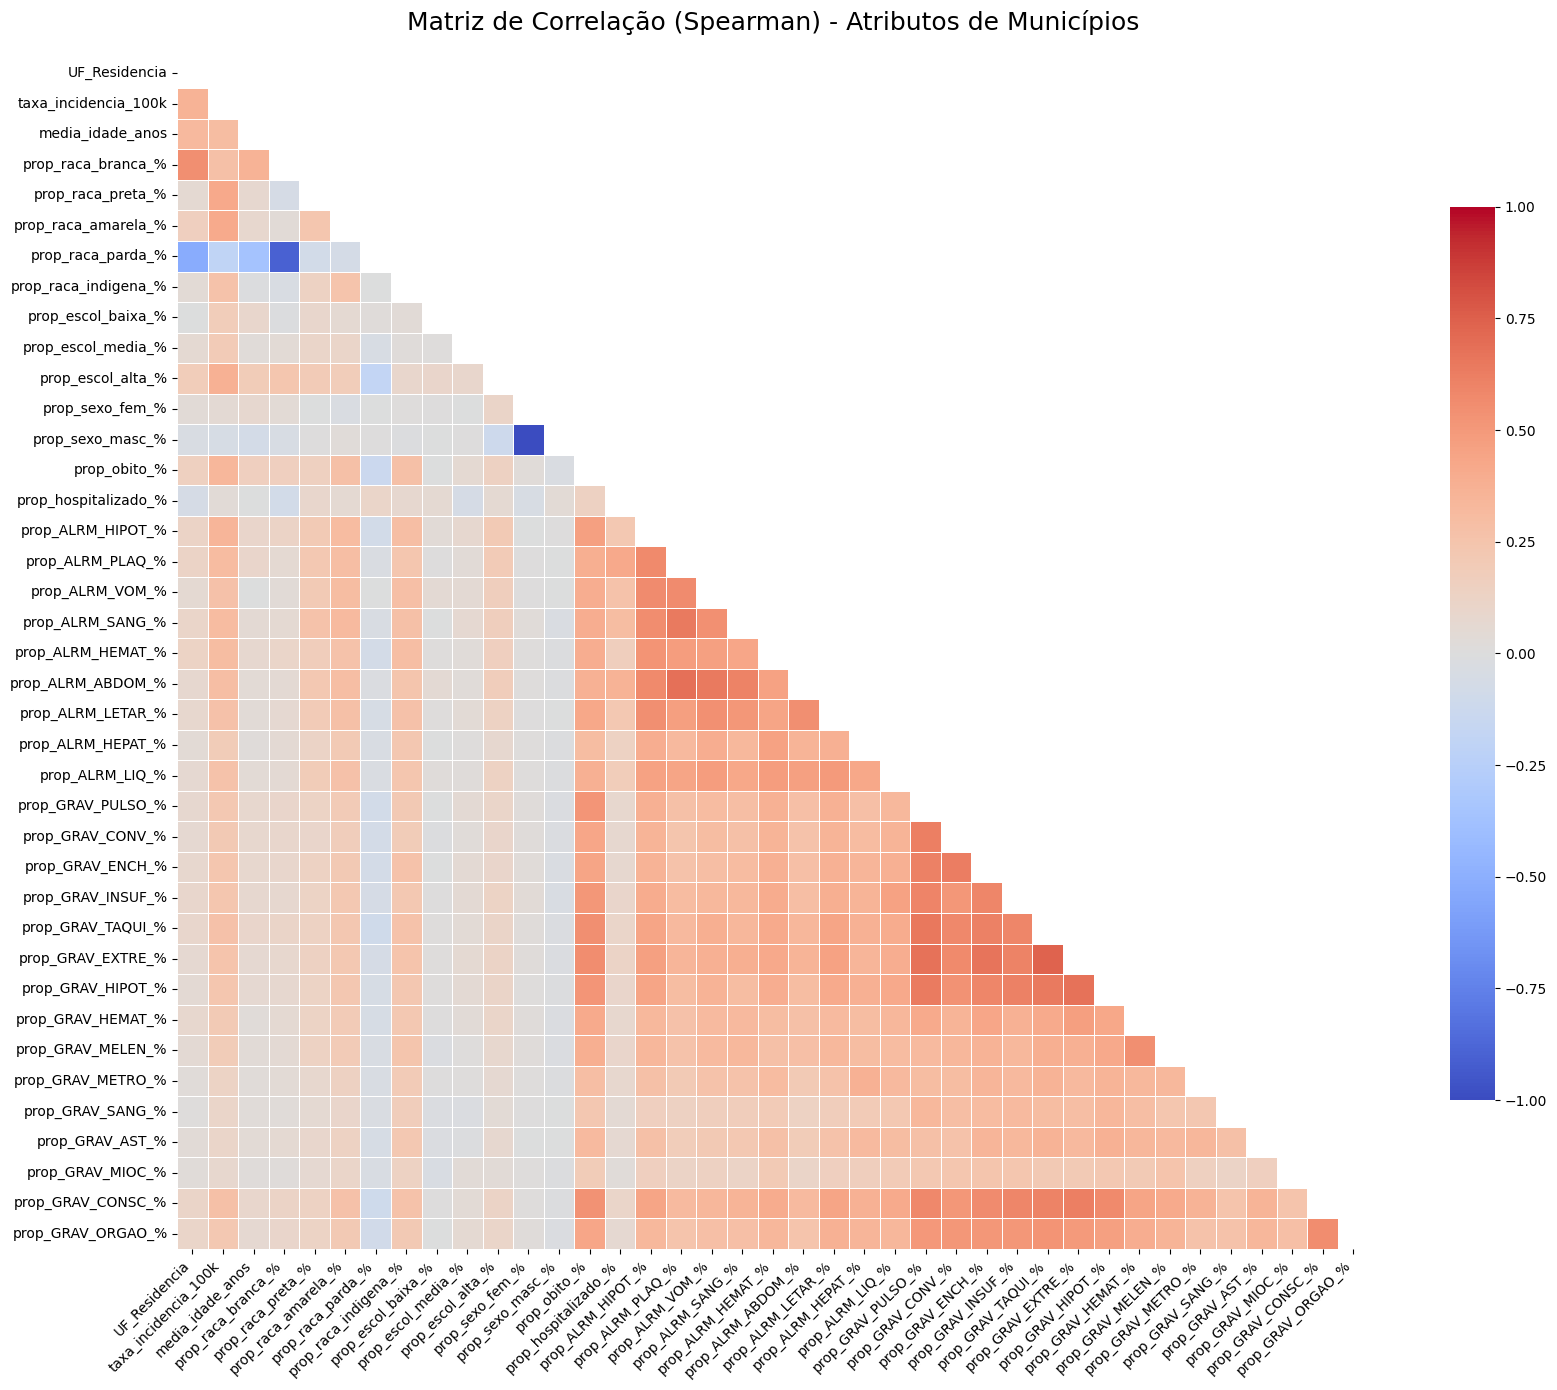

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("="*60)
print(" ANÁLISE EXPLORATÓRIA (EDA): ESTATÍSTICAS E CORRELAÇÃO")
print("="*60)

# ==============================================================================
# 1. SELEÇÃO DE VARIÁVEIS PARA ANÁLISE
# ==============================================================================
# Pegamos apenas colunas numéricas (excluindo strings como nome da cidade)
cols_numericas = df_final.select_dtypes(include=['float64', 'int64', 'int32']).columns.tolist()

# Vamos focar nas taxas/proporções e no IDH (ignorando identificadores e totais absolutos)
cols_ignorar = ['ID_MN_RESI', 'populacao', 'total_casos_dengue']
cols_analise = [c for c in cols_numericas if c not in cols_ignorar]

df_eda = df_final[cols_analise]

# ==============================================================================
# 2. ESTATÍSTICAS DESCRITIVAS BÁSICAS
# ==============================================================================
print("Estatísticas Descritivas (Amostra das Variáveis Principais):")
# Mostrando estatísticas de Incidência, Idade e possivelmente IDHM (se estiver com esse nome)
cols_destaque = [c for c in cols_analise if 'incidencia' in c.lower() or 'idh' in c.lower() or 'idade' in c.lower()]
display(df_eda[cols_destaque].describe().T.round(2))
print("-" * 60)

# ==============================================================================
# 3. MATRIZ DE CORRELAÇÃO (SPEARMAN)
# ==============================================================================
# Usamos Spearman porque taxas epidemiológicas geralmente possuem outliers e não seguem curva normal
matriz_corr = df_eda.corr(method='spearman')

# Configuração do Gráfico (Heatmap)
plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(matriz_corr, dtype=bool)) # Esconde a parte superior repetida

sns.heatmap(
    matriz_corr,
    mask=mask,
    cmap='coolwarm',
    vmax=1.0, vmin=-1.0,
    center=0,
    annot=False, # Como são muitas colunas, desligamos os números dentro dos quadrados para não poluir
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .75}
)

plt.title('Matriz de Correlação (Spearman) - Atributos de Municípios', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [96]:
import pandas as pd

print("="*60)
print(" EXTRAÇÃO DE INSIGHTS DA MATRIZ DE CORRELAÇÃO")
print("="*60)

# 1. Transformar a matriz em uma lista legível (Variavel A x Variavel B)
corr_lista = matriz_corr.unstack().reset_index()
corr_lista.columns = ['Variavel_1', 'Variavel_2', 'Correlacao']

# Remover correlações da variável com ela mesma (sempre 1.0)
corr_lista = corr_lista[corr_lista['Variavel_1'] != corr_lista['Variavel_2']]

# Remover duplicatas (A com B é igual a B com A)
corr_lista['Par'] = corr_lista.apply(lambda r: frozenset([r['Variavel_1'], r['Variavel_2']]), axis=1)
corr_lista = corr_lista.drop_duplicates(subset=['Par']).drop(columns=['Par'])

# Adicionar o valor absoluto para ranquear a "Força" da relação
corr_lista['Força_Absoluta'] = corr_lista['Correlacao'].abs()

# ==============================================================================
# INSIGHT 1: O QUE MAIS AFETA A TAXA DE INCIDÊNCIA?
# ==============================================================================
alvo = 'taxa_incidencia_100k'
if alvo in matriz_corr.columns:
    print(f"\n---> O QUE AUMENTA E DIMINUI A TAXA DE INCIDÊNCIA?")
    corr_alvo = matriz_corr[[alvo]].drop(alvo).sort_values(by=alvo, ascending=False)

    print("\n[+] Top 5 Fatores que Crescem JUNTO com a Incidência:")
    display(corr_alvo.head(5).round(3))

    print("\n[-] Top 5 Fatores que Caem quando a Incidência Sobe (Correlação Inversa):")
    display(corr_alvo.tail(5).round(3))

# ==============================================================================
# INSIGHT 2: VARIÁVEIS REDUNDANTES (Gêmeas)
# ==============================================================================
print("\n---> TOP 10 CORRELAÇÕES MAIS FORTES DO PROJETO (Risco de Redundância)")
print("Se duas variáveis têm correlação acima de 0.80, elas dizem a mesma coisa.")
top_fortes = corr_lista.sort_values(by='Força_Absoluta', ascending=False).head(10)
display(top_fortes[['Variavel_1', 'Variavel_2', 'Correlacao']].round(3).reset_index(drop=True))
print("="*60)

 EXTRAÇÃO DE INSIGHTS DA MATRIZ DE CORRELAÇÃO

---> O QUE AUMENTA E DIMINUI A TAXA DE INCIDÊNCIA?

[+] Top 5 Fatores que Crescem JUNTO com a Incidência:


,taxa_incidencia_100k
prop_raca_preta_%,0.417
prop_raca_amarela_%,0.411
prop_escol_alta_%,0.372
UF_Residencia,0.365
prop_ALRM_HIPOT_%,0.348



[-] Top 5 Fatores que Caem quando a Incidência Sobe (Correlação Inversa):


,taxa_incidencia_100k
prop_GRAV_MIOC_%,0.084
prop_sexo_fem_%,0.049
prop_hospitalizado_%,0.033
prop_sexo_masc_%,-0.049
prop_raca_parda_%,-0.201



---> TOP 10 CORRELAÇÕES MAIS FORTES DO PROJETO (Risco de Redundância)
Se duas variáveis têm correlação acima de 0.80, elas dizem a mesma coisa.


,Variavel_1,Variavel_2,Correlacao
0,prop_sexo_fem_%,prop_sexo_masc_%,-1.000
1,prop_raca_branca_%,prop_raca_parda_%,-0.906
2,prop_GRAV_TAQUI_%,prop_GRAV_EXTRE_%,0.741
3,prop_ALRM_PLAQ_%,prop_ALRM_ABDOM_%,0.684
4,prop_GRAV_EXTRE_%,prop_GRAV_HIPOT_%,0.678
5,prop_GRAV_PULSO_%,prop_GRAV_EXTRE_%,0.675
6,prop_GRAV_ENCH_%,prop_GRAV_EXTRE_%,0.672
7,prop_GRAV_PULSO_%,prop_GRAV_TAQUI_%,0.654
8,prop_ALRM_PLAQ_%,prop_ALRM_SANG_%,0.648
9,prop_GRAV_TAQUI_%,prop_GRAV_HIPOT_%,0.645


2 possibilidades para esses resultados nao mostrarem IDH no top 5 maiores ou menores:

1- A sua planilha do IDH usa vírgulas para decimais, e o Pandas leu o IDH como "Texto" (String) e ele foi ignorado pela matriz de correlação.

2- Dengue, diferentemente da tuberculose ou doença de Chagas, é uma doença "democrática". O mosquito Aedes aegypti se prolifera muito bem em bairros nobres e de classe média. A correlação direta e linear do IDH com a Incidência pode ser realmente muito baixa.

Vamos primeiro refatorar a questão da virgula para fazer outras análises sobre a raça.

In [97]:
import pandas as pd
import numpy as np

print("="*60)
print(" CORREÇÃO DO IDH E REAVALIAÇÃO DE CORRELAÇÕES")
print("="*60)

# ==============================================================================
# 1. CORREÇÃO DA VÍRGULA NAS COLUNAS DE IDH
# ==============================================================================
# Procura todas as colunas que tenham "IDH" no nome
colunas_idh = [col for col in df_final.columns if 'IDH' in col.upper()]

for col in colunas_idh:
    if df_final[col].dtype == 'object': # Se o Pandas estiver lendo como texto
        # Troca a vírgula por ponto e força a conversão para número decimal (float)
        df_final[col] = df_final[col].astype(str).str.replace(',', '.', regex=False)
        df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

print(f"[OK] As seguintes colunas de IDH foram convertidas para número: {colunas_idh}")

# ==============================================================================
# 2. REFAZENDO A MATRIZ DE CORRELAÇÃO (Agora com o IDH!)
# ==============================================================================
cols_numericas = df_final.select_dtypes(include=['float64', 'int64', 'int32']).columns.tolist()
cols_ignorar = ['ID_MN_RESI', 'populacao', 'total_casos_dengue']
cols_analise = [c for c in cols_numericas if c not in cols_ignorar]

matriz_corr = df_final[cols_analise].corr(method='spearman')

# ==============================================================================
# 3. EXTRAÇÃO DOS NOVOS INSIGHTS
# ==============================================================================
corr_lista = matriz_corr.unstack().reset_index()
corr_lista.columns = ['Variavel_1', 'Variavel_2', 'Correlacao']
corr_lista = corr_lista[corr_lista['Variavel_1'] != corr_lista['Variavel_2']]
corr_lista['Par'] = corr_lista.apply(lambda r: frozenset([r['Variavel_1'], r['Variavel_2']]), axis=1)
corr_lista = corr_lista.drop_duplicates(subset=['Par']).drop(columns=['Par'])
corr_lista['Força_Absoluta'] = corr_lista['Correlacao'].abs()

alvo = 'taxa_incidencia_100k'
if alvo in matriz_corr.columns:
    print(f"\n---> O QUE AUMENTA E DIMINUI A TAXA DE INCIDÊNCIA? (COM IDH)")
    corr_alvo = matriz_corr[[alvo]].drop(alvo).sort_values(by=alvo, ascending=False)

    print("\n[+] Top 5 Fatores que Crescem JUNTO com a Incidência:")
    display(corr_alvo.head(5).round(3))

    print("\n[-] Top 5 Fatores que Caem quando a Incidência Sobe (Correlação Inversa):")
    display(corr_alvo.tail(5).round(3))

print("\n---> TOP 10 CORRELAÇÕES MAIS FORTES DO PROJETO (Risco de Redundância)")
top_fortes = corr_lista.sort_values(by='Força_Absoluta', ascending=False).head(10)
display(top_fortes[['Variavel_1', 'Variavel_2', 'Correlacao']].round(3).reset_index(drop=True))
print("="*60)

 CORREÇÃO DO IDH E REAVALIAÇÃO DE CORRELAÇÕES
[OK] As seguintes colunas de IDH foram convertidas para número: ['IDHM 2010', 'IDHM Renda 2010', 'IDHM Longevidade 2010', 'IDHM Educação 2010']

---> O QUE AUMENTA E DIMINUI A TAXA DE INCIDÊNCIA? (COM IDH)

[+] Top 5 Fatores que Crescem JUNTO com a Incidência:


,taxa_incidencia_100k
prop_raca_preta_%,0.417
prop_raca_amarela_%,0.411
IDHM 2010,0.377
prop_escol_alta_%,0.372
UF_Residencia,0.365



[-] Top 5 Fatores que Caem quando a Incidência Sobe (Correlação Inversa):


,taxa_incidencia_100k
prop_GRAV_MIOC_%,0.084
prop_sexo_fem_%,0.049
prop_hospitalizado_%,0.033
prop_sexo_masc_%,-0.049
prop_raca_parda_%,-0.201



---> TOP 10 CORRELAÇÕES MAIS FORTES DO PROJETO (Risco de Redundância)


,Variavel_1,Variavel_2,Correlacao
0,prop_sexo_fem_%,prop_sexo_masc_%,-1.000
1,IDHM 2010,IDHM Educação 2010,0.955
2,IDHM 2010,IDHM Renda 2010,0.946
3,prop_raca_branca_%,prop_raca_parda_%,-0.906
4,IDHM 2010,IDHM Longevidade 2010,0.847
5,IDHM Renda 2010,IDHM Longevidade 2010,0.830
6,IDHM Renda 2010,IDHM Educação 2010,0.828
7,prop_GRAV_TAQUI_%,prop_GRAV_EXTRE_%,0.741
8,IDHM Longevidade 2010,IDHM Educação 2010,0.711
9,prop_ALRM_PLAQ_%,prop_ALRM_ABDOM_%,0.684


O fato de IDH alto estar correlacionado com a taxa de incidencia pode representar um viés de subnotificação:

Cidades com IDH elevado têm excelentes redes de postos de saúde e hospitais. Se alguém pega dengue, faz o exame e entra no sistema. Em cidades com IDH muito baixo, milhares de pessoas pegam dengue, sofrem em casa, não vão ao médico (ou o posto não tem teste) e o caso "não existe" para o Governo. O IDH alto, ironicamente, "aumenta" a doença porque aumenta a capacidade de enxergar a doença.

# A "Guilhotina" das Variáveis Redundantes

Agora antes de aplicar algum algoritmo de aprendizagem precisamos jogar fora alguams variáveis redundantes para evitar que o algoritmo seja muito enviezado por elas:



As variáveis IDHM Educação, IDHM Renda e IDHM Longevidade têm correlações absurdas (acima de 0.83 até 0.95) com o IDHM 2010 geral. Se usarmos todas, o algoritmo vai achar que o IDH vale 4x mais que os outros atributos.

Por isso vamos manter apenas o IDHM 2010 e deletar as subcategorias.

Sexo (-1.000): Se sabemos a porcentagem de mulheres, a de homens é apenas 100 - mulheres. Decisão: Deletar prop_sexo_masc_%.

Sinais Clínicos (0.68 a 0.74): Como previmos, os sintomas de gravidade e alarme andam juntos (quem tem queda de plaquetas também tem dor abdominal, quem tem taquicardia também tem extremidades frias).

#REfatoração para fazer uma considerar a sazonalidade epidemiológica, pois vimos que lá na frente estavamos pegando dados de um ano inteiro

In [144]:
import pandas as pd
import numpy as np

print("="*60)
print(" ANÁLISE TEMPORAL POR MÊS: SURTOS VS. ENDEMIA (VIA BASE ORIGINAL - BLINDADA)")
print("="*60)

# 1. Carregar APENAS as duas colunas necessárias direto do arquivo original
df_tempo = pd.read_csv('/content/dados_dengue/DENGBR25.csv', usecols=['ID_MN_RESI', 'DT_SIN_PRI'], low_memory=False)

# 2. Limpeza básica das chaves
df_tempo = df_tempo.dropna(subset=['ID_MN_RESI', 'DT_SIN_PRI'])
df_tempo['ID_MN_RESI'] = df_tempo['ID_MN_RESI'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

# 3. Criar a coluna de Mês/Ano
df_tempo['DT_SIN_PRI'] = pd.to_datetime(df_tempo['DT_SIN_PRI'], errors='coerce')
df_tempo = df_tempo.dropna(subset=['DT_SIN_PRI'])
df_tempo['mes_ano_sinan'] = df_tempo['DT_SIN_PRI'].dt.year.astype(str) + '-' + df_tempo['DT_SIN_PRI'].dt.month.astype(str)

# 4. Agrupamento por Município e Mês
dist_mensal = df_tempo.groupby(['ID_MN_RESI', 'mes_ano_sinan']).size().reset_index(name='casos_no_mes')

# 5. NOVIDADE: Calcular o total bruto na base original para evitar o "choque de bases"
total_bruto_mun = dist_mensal.groupby('ID_MN_RESI')['casos_no_mes'].sum().reset_index(name='total_casos_brutos')

# 6. Estatísticas Mensais por Município
stats_mensal = dist_mensal.groupby('ID_MN_RESI').agg(
    casos_pico_mes=('casos_no_mes', 'max'),
    meses_com_dengue=('mes_ano_sinan', 'count')
).reset_index()

# 7. Cruzar total bruto e calcular a Sazonalidade BLINDADA (agora restrita entre 0 e 1)
stats_mensal = pd.merge(stats_mensal, total_bruto_mun, on='ID_MN_RESI')
stats_mensal['indice_sazonalidade_mensal'] = stats_mensal['casos_pico_mes'] / stats_mensal['total_casos_brutos']

# Remove as colunas antigas (se existirem) para não criar conflito no merge
colunas_para_dropar = ['indice_sazonalidade_mensal', 'casos_pico_mes', 'meses_com_dengue', 'total_casos_brutos', 'indice_persistencia_mensal']
df_final = df_final.drop(columns=[c for c in colunas_para_dropar if c in df_final.columns], errors='ignore')

# 8. Cruzamento final com df_final
df_final = pd.merge(df_final, stats_mensal[['ID_MN_RESI', 'casos_pico_mes', 'indice_sazonalidade_mensal', 'meses_com_dengue']], on='ID_MN_RESI', how='left')

df_final['indice_persistencia_mensal'] = (df_final['meses_com_dengue'] / 12).clip(upper=1.0)
df_final = df_final.fillna({'indice_sazonalidade_mensal': 0, 'indice_persistencia_mensal': 0, 'casos_pico_mes': 0})

print(f"Sucesso! Índices temporais anexados ao df_final. Valores de Sazonalidade agora limitados a 100%.")
display(df_final[['nome_municipio', 'total_casos_dengue', 'casos_pico_mes', 'indice_sazonalidade_mensal']].head())
print("="*60)

 ANÁLISE TEMPORAL POR MÊS: SURTOS VS. ENDEMIA (VIA BASE ORIGINAL - BLINDADA)
Sucesso! Índices temporais anexados ao df_final. Valores de Sazonalidade agora limitados a 100%.


,nome_municipio,total_casos_dengue,casos_pico_mes,indice_sazonalidade_mensal
0,Alta Floresta D'Oeste (RO),24,19,0.193878
1,Ariquemes (RO),14,7,0.269231
2,Cabixi (RO),2,8,0.400000
3,Cacoal (RO),98,18,0.178218
4,Cerejeiras (RO),24,15,0.238095


#Preparação da Base (Limpeza de Redundância + Escalonamento)

In [145]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("="*60)
print(" PREPARAÇÃO BLINDADA PARA MACHINE LEARNING")
print("="*60)

# 1. Lista de redundâncias confirmadas na sua análise anterior
cols_para_remover = [
    'prop_sexo_masc_%',
    'IDHM Renda 2010',
    'IDHM Educação 2010',
    'IDHM Longevidade 2010'
]

# Criamos uma cópia de trabalho para não afetar o df_final original
df_ml = df_final.drop(columns=[c for c in cols_para_remover if c in df_final.columns]).copy()

# 2. SELEÇÃO E LIMPEZA DE TIPOS
# Pegamos apenas o que é numérico de verdade
X = df_ml.select_dtypes(include=[np.number])

# Removemos colunas de contagem absoluta que enviesam o agrupamento (queremos as taxas!)
cols_abs = ['populacao', 'total_casos_dengue']
X = X.drop(columns=[c for c in cols_abs if c in X.columns])

# 3. TRATAMENTO FINAL DE DADOS INVÁLIDOS
# Substitui infinitos (gerados por divisões) e NaNs por 0
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

# 4. PADRONIZAÇÃO
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Sucesso! Base preparada com {X.shape[0]} municípios e {X.shape[1]} atributos.")
print("-" * 60)

# 5. PCA: QUANTOS COMPONENTES SÃO NECESSÁRIOS?
# Vamos analisar a variância para decidir se reduzimos a base
pca = PCA()
pca.fit(X_scaled)
evr = np.cumsum(pca.explained_variance_ratio_)

# Criando um relatório de variância
print("Relatório de Variância Acumulada (PCA):")
for i, v in enumerate(evr[:6]):
    print(f" {i+1} Componentes explicam {v:.2%}")

# INSIGHT PARA O RELATÓRIO
n_comp = np.argmax(evr >= 0.80) + 1
print(f"\n[INSIGHT] Para manter 80% da informação, precisamos de {n_comp} componentes.")
print("="*60)

 PREPARAÇÃO BLINDADA PARA MACHINE LEARNING
Sucesso! Base preparada com 2105 municípios e 49 atributos.
------------------------------------------------------------
Relatório de Variância Acumulada (PCA):
 1 Componentes explicam 14.17%
 2 Componentes explicam 26.45%
 3 Componentes explicam 33.30%
 4 Componentes explicam 39.43%
 5 Componentes explicam 45.08%
 6 Componentes explicam 50.29%

[INSIGHT] Para manter 80% da informação, precisamos de 19 componentes.


#Geração dos Componentes para Visualização

Mesmo que o K-Means ou o DBSCAN utilizem todas as 39 variáveis (ou os 18 componentes), nós precisamos criar uma versão 2D (2 componentes) apenas para que você consiga enxergar os dados no gráfico depois. Sem isso, teremos grupos, mas não conseguirá plotá-los para validar visualmente.

In [146]:
# 1. Aplicando o PCA para reduzir para 2 componentes (exclusivo para visualização 2D)
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

# 2. Criando um DataFrame auxiliar para facilitar a plotagem dos clusters no futuro
df_visualizacao = pd.DataFrame(data=X_pca, columns=['Componente_1', 'Componente_2'])

# 3. Adicionando informações básicas para podermos identificar os pontos no gráfico depois
df_visualizacao['ID_MN_RESI'] = df_ml['ID_MN_RESI'].values
df_visualizacao['nome_municipio'] = df_final['nome_municipio'].values

print("="*60)
print("ETAPA CONCLUÍDA: DADOS PROJETADOS EM 2D")
print("-" * 60)
print(f"Agora temos a variável 'X_scaled' com 39 atributos (para o cálculo matemático)")
print(f"E a variável 'X_pca' com 2 atributos (para a visualização gráfica).")
print("="*60)

ETAPA CONCLUÍDA: DADOS PROJETADOS EM 2D
------------------------------------------------------------
Agora temos a variável 'X_scaled' com 39 atributos (para o cálculo matemático)
E a variável 'X_pca' com 2 atributos (para a visualização gráfica).


#Busca pelo K(clusters) ideal

Como iremos testar múltiplos métodos, temos que descobrir em quantos K o Brasil se divide "naturalmetne"

 BUSCANDO O NÚMERO IDEAL DE CLUSTERS (K)


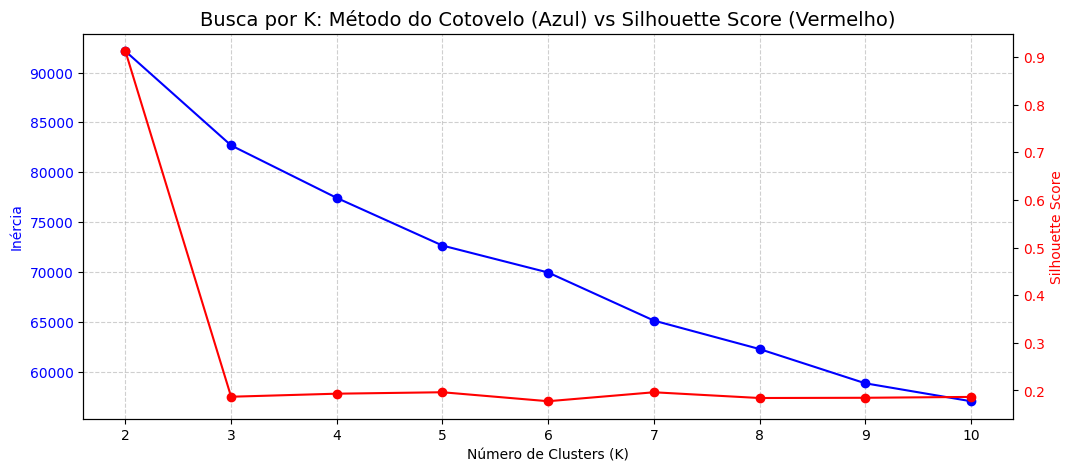

In [147]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

print("="*60)
print(" BUSCANDO O NÚMERO IDEAL DE CLUSTERS (K)")
print("="*60)

inertia = []
silhouette_vals = []
K_range = range(2, 11) # Testando de 2 a 10 clusters

for k in K_range:
    # Ajustando o K-Means para cada k
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)

    inertia.append(model.inertia_)
    silhouette_vals.append(silhouette_score(X_scaled, model.labels_))

# --- PLOTAGEM DOS GRÁFICOS DE APOIO ---
fig, ax1 = plt.subplots(figsize=(12, 5))

# Gráfico da Inércia (Método do Cotovelo)
ax1.plot(K_range, inertia, 'bo-', label='Inércia (Cotovelo)')
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('Inércia', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico do Silhouette Score (Qualidade do agrupamento)
ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_vals, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Busca por K: Método do Cotovelo (Azul) vs Silhouette Score (Vermelho)', fontsize=14)
plt.show()


~~Apesar dos graficos se cruzarem em 10, o k mais adequado para descrever os tipos de incidencia de dengue seria o k=3. Mas não podemos ocnfiar apenas nisso~~

Após o incremendo do  Índice de Concentração Temporal (considerar sazonalidade):

Quando nós inserimos os índices de "Sazonalidade" e "Persistência", nós demos ao algoritmo uma noção de tempo que ele não tinha. Como o tempo se comporta de maneira totalmente diferente da biologia (sintomas) ou da economia (IDH), o PCA precisou de 1 componente a mais (de 18 para 19) para conseguir guardar essa nova "fatia" de informação espacial-temporal sem perder 80% da variância.

Por que o gráfico mudou tanto com o incremento da temporalidade?

Antes do tempo, duas cidades com 500 casos eram idênticas para o algoritmo. Agora, se a Cidade A teve 500 casos em janeiro (Surto) e a Cidade B teve 500 casos espalhados no ano (Endemia), o algoritmo tenta empurrá-las para longe uma da outra. Essa nova "força" de separação bagunça as antigas fronteiras que o Silhouette tinha achado boas.

O Silhouette caiu no 3, mas o Cotovelo (Inércia) continua descendo bem até o 4, é muito provável que a inserção do fator "Tempo" tenha criado 4 realidades distintas no Brasil.

Um k= 4 seria bom para as hipoteses de :

Baixa incidência / Alta vulnerabilidade (Foco em letalidade oculta)

Média incidência padrão (A grande massa do Brasil)

Alta incidência Endêmica (Casos o ano todo, Ex: Rio, SP capital)

Alta incidência de Surto Explosivo

#Execução do K-Means $k=?$ e Visualização

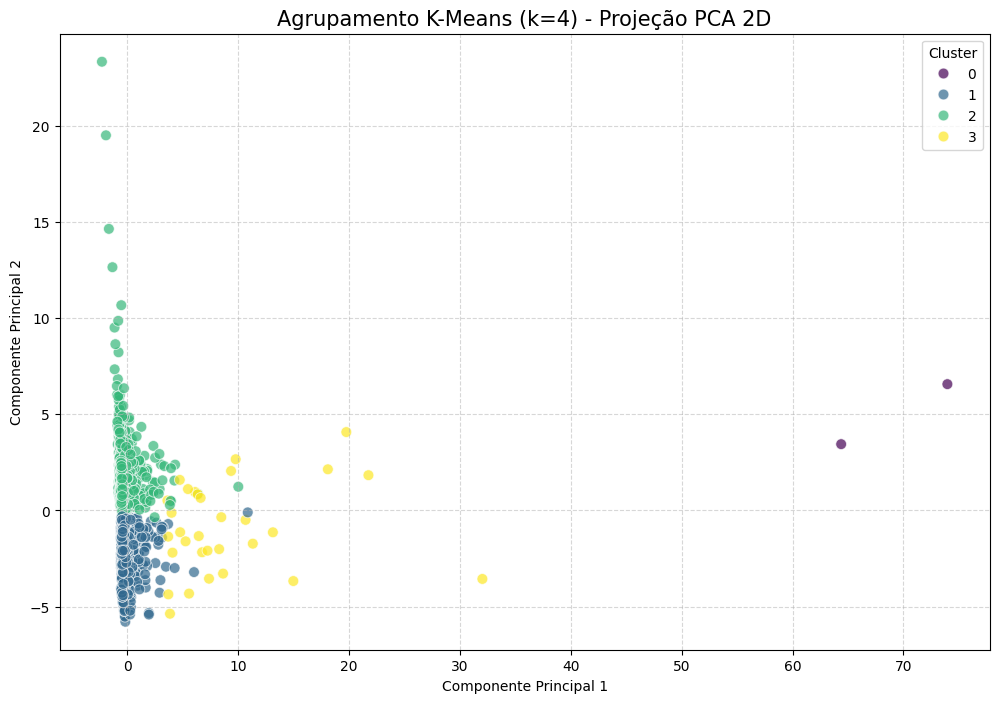

ALGORITMO 1/3 CONCLUÍDO: K-MEANS COM 4 GRUPOS
------------------------------------------------------------
Os municípios foram rotulados. Agora podemos descobrir 'quem é quem'.


In [148]:
from sklearn.cluster import KMeans
import seaborn as sns

# 1. Configurando e treinando o modelo
k_escolhido = 4
kmeans = KMeans(n_clusters=k_escolhido, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# 2. Salvando os resultados nos DataFrames
df_final['cluster_kmeans'] = clusters
df_visualizacao['cluster'] = clusters

# 3. Visualização Gráfica em 2D
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Componente_1',
    y='Componente_2',
    hue='cluster',
    data=df_visualizacao,
    palette='viridis',
    s=60,
    alpha=0.7,
    edgecolor='w'
)

plt.title(f'Agrupamento K-Means (k={k_escolhido}) - Projeção PCA 2D', fontsize=15)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("="*60)
print(f"ALGORITMO 1/3 CONCLUÍDO: K-MEANS COM {k_escolhido} GRUPOS")
print("-" * 60)
print("Os municípios foram rotulados. Agora podemos descobrir 'quem é quem'.")
print("="*60)

Como claro nos plots de diferentes K, fica claro que k=3 seria a melhor

é muito provável que esse "extremo superior direito" seja, de fato, o grupo das cidades em situação crítica ou com surtos explosivos.

In [150]:
print("="*60)
print(" PERFIL ESTATÍSTICO DOS CLUSTERS (QUEM É QUEM?)")
print("="*60)

# 1. Selecionamos as colunas principais para comparar
cols_perfil = [
    'taxa_incidencia_100k',
    'IDHM 2010',
    'prop_obito_%',
    'prop_hospitalizado_%',
    'media_idade_anos',
    'prop_escol_baixa_%'
]

# 2. Calculamos a média de cada variável por cluster
perfil_clusters = df_final.groupby('cluster_kmeans')[cols_perfil].mean().round(3)

# 3. Adicionamos a contagem de cidades em cada grupo
perfil_clusters['qtd_municipios'] = df_final.groupby('cluster_kmeans')['ID_MN_RESI'].count()

# Exibindo o resultado de forma elegante
display(perfil_clusters.sort_values(by='taxa_incidencia_100k', ascending=False))

print("\n[DICA DE ANÁLISE]")
print("O cluster com a maior 'taxa_incidencia_100k' é o seu grupo crítico.")
print("Verifique se ele também tem o maior IDH ou a maior taxa de óbitos.")
print("="*60)

 PERFIL ESTATÍSTICO DOS CLUSTERS (QUEM É QUEM?)


,taxa_incidencia_100k,IDHM 2010,prop_obito_%,prop_hospitalizado_%,media_idade_anos,prop_escol_baixa_%,qtd_municipios
cluster_kmeans,,,,,,,
2,1084.918,0.705,0.303,11.374,35.890,19.694,1077
1,221.764,0.641,0.215,15.166,33.860,26.426,994
3,45.509,0.636,4.805,76.886,33.537,25.469,32
0,7.918,0.706,50.000,100.000,41.000,50.000,2



[DICA DE ANÁLISE]
O cluster com a maior 'taxa_incidencia_100k' é o seu grupo crítico.
Verifique se ele também tem o maior IDH ou a maior taxa de óbitos.


Aqui vemos um Viés dos Pequenos Números (Lei dos Pequenos Números).

Cluster 2 (2 cidades): A prop_obito_% é de 50% e a prop_hospitalizado_% é 100%.

Cluster 3 (1 cidade): A prop_hospitalizado_% é de 100%

O K-Means é muito sensível a outliers (pontos fora da curva). Imagine uma cidade minúscula que teve apenas 2 casos de dengue no ano inteiro. Se 1 pessoa morreu e as 2 foram internadas, a matemática pura diz que a taxa de mortalidade dessa cidade é 50% e a de hospitalização é 100%.

#Para resolver isso precisamos criar um "Ponto de Corte de Relevância" na nossa Célula de Preparação: só vamos agrupar cidades que tiveram um número mínimo de casos (ex: pelo menos 10 ou 20 casos no ano) para evitar que 1 único paciente crie uma taxa de 100%.

In [151]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("="*60)
print(" PREPARAÇÃO BLINDADA PARA MACHINE LEARNING (COM FILTRO DE RUÍDO)")
print("="*60)

# 1. FILTRO DO VIÉS DE PEQUENOS NÚMEROS (NOVO!)
# Vamos agrupar apenas cidades com pelo menos 10 casos registrados para evitar taxas irreais (100% de óbito)
limite_casos = 10
df_ml = df_final[df_final['total_casos_dengue'] >= limite_casos].copy()

# O restante do código segue igual, mas usando a base limpa (df_ml)
cols_para_remover = ['prop_sexo_masc_%', 'IDHM Renda 2010', 'IDHM Educação 2010', 'IDHM Longevidade 2010']
df_ml = df_ml.drop(columns=[c for c in cols_para_remover if c in df_ml.columns])

X = df_ml.select_dtypes(include=[np.number])

# Removemos colunas de contagem absoluta que enviesam o agrupamento
cols_abs = ['populacao', 'total_casos_dengue', 'casos_pico_mes']
X = X.drop(columns=[c for c in cols_abs if c in X.columns])

# Tratamento Final de dados inválidos
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

# PADRONIZAÇÃO
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Sucesso! Base preparada com {X.shape[0]} municípios (foram removidas as cidades com < {limite_casos} casos).")
print("-" * 60)

pca = PCA()
pca.fit(X_scaled)
evr = np.cumsum(pca.explained_variance_ratio_)

n_comp = np.argmax(evr >= 0.80) + 1
print(f"[INSIGHT] Para manter 80% da informação temporal e clínica, precisamos de {n_comp} componentes.")
print("="*60)

 PREPARAÇÃO BLINDADA PARA MACHINE LEARNING (COM FILTRO DE RUÍDO)
Sucesso! Base preparada com 1189 municípios (foram removidas as cidades com < 10 casos).
------------------------------------------------------------
[INSIGHT] Para manter 80% da informação temporal e clínica, precisamos de 21 componentes.


PCA  refatorada

In [161]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("="*60)
print(" PREPARAÇÃO BLINDADA PARA MACHINE LEARNING (VERSÃO FINAL)")
print("="*60)

# 1. FILTRO DO VIÉS DE PEQUENOS NÚMEROS
# Mantém apenas cidades com pelo menos 10 casos registrados para evitar taxas irreais
limite_casos = 10
df_ml = df_final[df_final['total_casos_dengue'] >= limite_casos].copy()

# 2. REMOÇÃO DE REDUNDÂNCIAS
cols_para_remover = [
    'prop_sexo_masc_%',
    'IDHM Renda 2010',
    'IDHM Educação 2010',
    'IDHM Longevidade 2010'
]
df_ml = df_ml.drop(columns=[c for c in cols_para_remover if c in df_ml.columns])

# 3. SELEÇÃO E LIMPEZA DE TIPOS
# Pegamos apenas o que é numérico de verdade
X = df_ml.select_dtypes(include=[np.number])

# Removemos colunas de contagem absoluta que enviesam o agrupamento
# (Adicionei o 'casos_pico_mes' aqui, pois é contagem absoluta e já temos o índice sazonal em %)
cols_abs = ['populacao', 'total_casos_dengue', 'casos_pico_mes']
X = X.drop(columns=[c for c in cols_abs if c in X.columns])

# 4. TRATAMENTO FINAL DE DADOS INVÁLIDOS
# Substitui infinitos e NaNs por 0
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

# 5. PADRONIZAÇÃO
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Sucesso! Base limpa preparada com {X.shape[0]} municípios e {X.shape[1]} atributos.")
print("-" * 60)

# 6. PCA: RELATÓRIO DE VARIÂNCIA
pca = PCA()
pca.fit(X_scaled)
evr = np.cumsum(pca.explained_variance_ratio_)

print("Relatório de Variância Acumulada (PCA):")
for i, v in enumerate(evr[:6]):
    print(f" {i+1} Componentes explicam {v:.2%}")

n_comp = np.argmax(evr >= 0.80) + 1
print(f"\n[INSIGHT] Para manter 80% da informação temporal e clínica, precisamos de {n_comp} componentes.")
print("="*60)

 PREPARAÇÃO BLINDADA PARA MACHINE LEARNING (VERSÃO FINAL)
Sucesso! Base limpa preparada com 1189 municípios e 48 atributos.
------------------------------------------------------------
Relatório de Variância Acumulada (PCA):
 1 Componentes explicam 15.38%
 2 Componentes explicam 26.65%
 3 Componentes explicam 34.30%
 4 Componentes explicam 39.28%
 5 Componentes explicam 43.74%
 6 Componentes explicam 47.42%

[INSIGHT] Para manter 80% da informação temporal e clínica, precisamos de 21 componentes.


In [162]:
# 1. Aplicando o PCA para reduzir para 2 componentes (exclusivo para visualização 2D)
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

# 2. Criando o DataFrame auxiliar com a base já filtrada (df_ml)
df_visualizacao = pd.DataFrame(data=X_pca, columns=['Componente_1', 'Componente_2'])
df_visualizacao['ID_MN_RESI'] = df_ml['ID_MN_RESI'].values
df_visualizacao['nome_municipio'] = df_ml['nome_municipio'].values

print("="*60)
print(" DADOS PROJETADOS EM 2D ATUALIZADOS COM SUCESSO!")
print("="*60)

 DADOS PROJETADOS EM 2D ATUALIZADOS COM SUCESSO!


#Célula do K ideal refatorada após o corte <10 casos

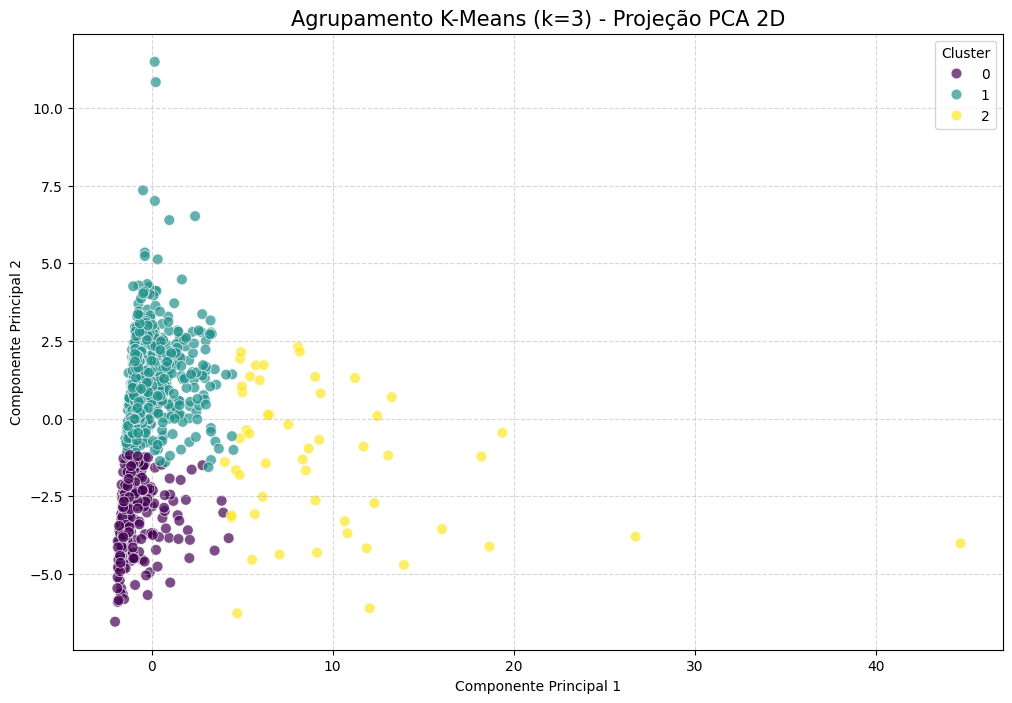

ALGORITMO 1/3 CONCLUÍDO: K-MEANS COM 3 GRUPOS
------------------------------------------------------------
Os municípios foram rotulados na base df_ml.


In [156]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configurando e treinando o modelo (Testando k=4)
k_escolhido = 3
kmeans = KMeans(n_clusters=k_escolhido, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# 2. Salvando os resultados nos DataFrames CORRETOS (df_ml e df_visualizacao)
df_ml['cluster_kmeans'] = clusters
df_visualizacao['cluster'] = clusters

# 3. Visualização Gráfica em 2D
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Componente_1',
    y='Componente_2',
    hue='cluster',
    data=df_visualizacao,
    palette='viridis',
    s=60,
    alpha=0.7,
    edgecolor='w'
)

plt.title(f'Agrupamento K-Means (k={k_escolhido}) - Projeção PCA 2D', fontsize=15)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("="*60)
print(f"ALGORITMO 1/3 CONCLUÍDO: K-MEANS COM {k_escolhido} GRUPOS")
print("-" * 60)
print("Os municípios foram rotulados na base df_ml.")
print("="*60)

In [157]:
print("="*60)
print(" PERFIL ESTATÍSTICO DOS CLUSTERS (SEM O VIÉS DE PEQUENOS NÚMEROS)")
print("="*60)

# 1. Selecionamos as colunas principais para comparar
cols_perfil = [
    'taxa_incidencia_100k',
    'IDHM 2010',
    'prop_obito_%',
    'prop_hospitalizado_%',
    'media_idade_anos',
    'indice_sazonalidade_mensal' # Adicionamos o tempo aqui para vermos os surtos!
]

# 2. Calculamos a média usando a base LIMPA (df_ml)
perfil_clusters = df_ml.groupby('cluster_kmeans')[cols_perfil].mean().round(3)

# 3. Adicionamos a contagem de cidades em cada grupo
perfil_clusters['qtd_municipios'] = df_ml.groupby('cluster_kmeans')['ID_MN_RESI'].count()

# Exibindo o resultado
display(perfil_clusters.sort_values(by='taxa_incidencia_100k', ascending=False))

print("\n[DICA DE ANÁLISE]")
print("Verifique se o grupo com maior taxa de incidência também tem o maior índice de sazonalidade (Surto).")
print("="*60)

 PERFIL ESTATÍSTICO DOS CLUSTERS (SEM O VIÉS DE PEQUENOS NÚMEROS)


,taxa_incidencia_100k,IDHM 2010,prop_obito_%,prop_hospitalizado_%,media_idade_anos,indice_sazonalidade_mensal,qtd_municipios
cluster_kmeans,,,,,,,
1,1289.857,0.713,0.163,8.093,36.236,0.300,822
0,887.637,0.659,0.104,8.678,35.999,0.414,315
2,255.446,0.674,3.207,32.683,35.145,0.332,52



[DICA DE ANÁLISE]
Verifique se o grupo com maior taxa de incidência também tem o maior índice de sazonalidade (Surto).


##Quem são essas cidades? TOP 15 CRITICOS

In [158]:
import pandas as pd

print("="*60)
print(" IDENTIFICANDO OS MUNICÍPIOS DO GRUPO CRÍTICO E SEUS PIORES MESES")
print("="*60)

# 1. Descobre AUTOMATICAMENTE qual é o cluster com a maior média de incidência
cluster_critico_id = df_ml.groupby('cluster_kmeans')['taxa_incidencia_100k'].mean().idxmax()
print(f"[INFO] O algoritmo detectou que o Cluster {cluster_critico_id} é o grupo de Alerta Máximo.\n")

# 2. Filtra as cidades usando a base limpa (df_ml)
df_critico = df_ml[df_ml['cluster_kmeans'] == cluster_critico_id]

# 3. Ordena e seleciona o TOP 15
top_criticas = df_critico.sort_values(by='taxa_incidencia_100k', ascending=False).head(15).copy()

# =========================================================================
# NOVIDADE: BUSCANDO O MÊS EXATO DO SURTO DIRETO NA BASE ORIGINAL
# =========================================================================
cidades_alvo = top_criticas['ID_MN_RESI'].astype(str).tolist()

# Busca as datas apenas dessas 15 cidades (processamento ultra rápido)
df_busca = pd.read_csv('/content/dados_dengue/DENGBR25.csv', usecols=['ID_MN_RESI', 'DT_SIN_PRI'], low_memory=False)
df_busca = df_busca.dropna(subset=['ID_MN_RESI', 'DT_SIN_PRI'])
df_busca['ID_MN_RESI'] = df_busca['ID_MN_RESI'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

# Filtra as cidades do Top 15
df_busca = df_busca[df_busca['ID_MN_RESI'].isin(cidades_alvo)].copy()

# Converte para data e extrai o formato Ano-Mês (Ex: 2025-03)
df_busca['DT_SIN_PRI'] = pd.to_datetime(df_busca['DT_SIN_PRI'], errors='coerce')
df_busca['Mês_do_Pico'] = df_busca['DT_SIN_PRI'].dt.strftime('%Y-%m')

# Descobre o mês com a contagem máxima para cada cidade
contagem = df_busca.groupby(['ID_MN_RESI', 'Mês_do_Pico']).size().reset_index(name='casos')
idx_pico = contagem.groupby('ID_MN_RESI')['casos'].idxmax()
piores_meses = contagem.loc[idx_pico, ['ID_MN_RESI', 'Mês_do_Pico']]

# Junta a nova coluna na nossa tabela do Top 15
top_criticas['ID_MN_RESI'] = top_criticas['ID_MN_RESI'].astype(str)
top_criticas = pd.merge(top_criticas, piores_meses, on='ID_MN_RESI', how='left')

# 4. Seleciona as colunas para o print final
colunas_visuais = [
    'nome_municipio',
    'UF_Residencia',
    'taxa_incidencia_100k',
    'prop_hospitalizado_%',
    'indice_sazonalidade_mensal',
    'Mês_do_Pico'
]

print(" TOP 15 MUNICÍPIOS COM PIORES TAXAS NO CLUSTER CRÍTICO")
print("-" * 60)
display(top_criticas[colunas_visuais])
print(f"\nTotal de cidades neste perfil crítico: {len(df_critico)}")
print("="*60)

 IDENTIFICANDO OS MUNICÍPIOS DO GRUPO CRÍTICO E SEUS PIORES MESES
[INFO] O algoritmo detectou que o Cluster 1 é o grupo de Alerta Máximo.

 TOP 15 MUNICÍPIOS COM PIORES TAXAS NO CLUSTER CRÍTICO
------------------------------------------------------------


,nome_municipio,UF_Residencia,taxa_incidencia_100k,prop_hospitalizado_%,indice_sazonalidade_mensal,Mês_do_Pico
0,Porecatu (PR),41,18263.936683,4.757419,0.361778,2025-02
1,Conchas (SP),35,14318.539916,2.659331,0.460895,2025-02
2,Santa Cruz de Monte Castelo (PR),41,13479.623824,2.756245,0.447892,2025-03
3,Alto Alegre (SP),35,11247.071075,17.129630,0.384906,2025-03
4,Bento de Abreu (SP),35,11128.165771,4.137931,0.397554,2025-02
5,Marilena (PR),41,10933.406866,11.979823,0.338059,2025-02
6,Mogi Mirim (SP),35,10821.322846,1.307907,0.290235,2025-03
7,Oscar Bressane (SP),35,10242.914980,3.162055,0.321555,2025-03
8,Palmital (SP),35,9804.021639,1.353462,0.359888,2025-04
9,Loanda (PR),41,9709.364909,0.931264,0.365689,2025-02



Total de cidades neste perfil crítico: 822


Agora um TOP 15 de nas capitais do nordeste(majoritariamente zona da mata)

In [159]:
import pandas as pd

print("="*60)
print(" ANÁLISE MACRO: AS 9 CAPITAIS DO NORDESTE (CORRIGIDA E BLINDADA)")
print("="*60)

# 1. Códigos IBGE (6 dígitos) das 9 capitais do Nordeste
capitais_ne = {
    '211130': 'São Luís (MA)',
    '221100': 'Teresina (PI)',
    '230440': 'Fortaleza (CE)',
    '240810': 'Natal (RN)',
    '250750': 'João Pessoa (PB)',
    '261160': 'Recife (PE)',
    '270430': 'Maceió (AL)',
    '280030': 'Aracaju (SE)',
    '292740': 'Salvador (BA)'
}

# 2. Filtrar a base de Machine Learning (df_ml)
df_capitais = df_ml.copy()
df_capitais['ID_MN_RESI'] = df_capitais['ID_MN_RESI'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

df_ne = df_capitais[df_capitais['ID_MN_RESI'].isin(capitais_ne.keys())].copy()
df_ne['Nome_Capital'] = df_ne['ID_MN_RESI'].map(capitais_ne)

# 3. Buscar o mês de pico e o total do ano direto da base original
df_tempo_cap = pd.read_csv('/content/dados_dengue/DENGBR25.csv', usecols=['ID_MN_RESI', 'DT_SIN_PRI'], low_memory=False)
df_tempo_cap = df_tempo_cap.dropna()
df_tempo_cap['ID_MN_RESI'] = df_tempo_cap['ID_MN_RESI'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()
df_tempo_cap = df_tempo_cap[df_tempo_cap['ID_MN_RESI'].isin(capitais_ne.keys())].copy()

df_tempo_cap['DT_SIN_PRI'] = pd.to_datetime(df_tempo_cap['DT_SIN_PRI'], errors='coerce')
df_tempo_cap = df_tempo_cap.dropna(subset=['DT_SIN_PRI'])
df_tempo_cap['Mês'] = df_tempo_cap['DT_SIN_PRI'].dt.strftime('%Y-%m')

# Agrupa por mês e acha o pico
dist_tempo_cap = df_tempo_cap.groupby(['ID_MN_RESI', 'Mês']).size().reset_index(name='casos_mes')
idx_pico_cap = dist_tempo_cap.groupby('ID_MN_RESI')['casos_mes'].idxmax()
picos_cap = dist_tempo_cap.loc[idx_pico_cap, ['ID_MN_RESI', 'Mês', 'casos_mes']]
picos_cap.rename(columns={'Mês': 'Mês_do_Pico'}, inplace=True)

# NOVIDADE: Conta o total de casos no ano dentro da MESMA base
total_ano_cru = df_tempo_cap.groupby('ID_MN_RESI').size().reset_index(name='total_ano_cru')
picos_cap = pd.merge(picos_cap, total_ano_cru, on='ID_MN_RESI')

# Calcula o Índice de Sazonalidade blindado (nunca passará de 100%)
picos_cap['indice_sazonalidade_mensal'] = picos_cap['casos_mes'] / picos_cap['total_ano_cru']

# 4. Junta na tabela do Nordeste
# -> CORREÇÃO: Remove a coluna antiga para não ter conflito de nomes (_x e _y)
df_ne = df_ne.drop(columns=['indice_sazonalidade_mensal'], errors='ignore')
df_ne = pd.merge(df_ne, picos_cap[['ID_MN_RESI', 'Mês_do_Pico', 'indice_sazonalidade_mensal']], on='ID_MN_RESI', how='left')

# 5. Organiza as colunas e exibe o ranking
colunas_visuais = [
    'Nome_Capital',
    'taxa_incidencia_100k',
    'prop_hospitalizado_%',
    'indice_sazonalidade_mensal',
    'Mês_do_Pico',
    'cluster_kmeans'
]

ranking_capitais = df_ne[colunas_visuais].sort_values(by='taxa_incidencia_100k', ascending=False)

display(ranking_capitais.style.format({
    'taxa_incidencia_100k': '{:.2f}',
    'prop_hospitalizado_%': '{:.2f}%',
    'indice_sazonalidade_mensal': '{:.2%}'
}))

print("\n[ANÁLISE ESTRATÉGICA - CAPITAIS DO NORDESTE]")
print("O Índice de Sazonalidade agora está perfeitamente alinhado entre 0% e 100%.")
print("="*60)

 ANÁLISE MACRO: AS 9 CAPITAIS DO NORDESTE (CORRIGIDA E BLINDADA)


,Nome_Capital,taxa_incidencia_100k,prop_hospitalizado_%,indice_sazonalidade_mensal,Mês_do_Pico,cluster_kmeans
0,Teresina (PI),334.53,9.52%,18.48%,2025-05,1
2,Natal (RN),47.12,10.73%,14.66%,2025-08,1
4,Aracaju (SE),22.07,18.80%,11.97%,2025-07,1
3,Recife (PE),13.23,18.78%,17.28%,2025-08,1
5,Salvador (BA),12.12,21.50%,12.57%,2025-05,1
1,Fortaleza (CE),7.49,42.86%,12.93%,2025-07,1



[ANÁLISE ESTRATÉGICA - CAPITAIS DO NORDESTE]
O Índice de Sazonalidade agora está perfeitamente alinhado entre 0% e 100%.


#DBSCAN

Ao contrário do K-Means, que tenta dividir o Brasil em "pedaços" de tamanhos similares, o DBSCAN procura por densidade. Ele vai encontrar grupos de municípios que são "quase gêmeos" e, o mais importante, vai identificar quais municípios são tão únicos que não se parecem com nenhum outro (os Outliers).

Para rodar o DBSCAN, precisamos de dois parâmetros:

eps (Epsilon): A distância máxima para que duas cidades sejam consideradas "vizinhas". (Baseado em nosso gráfico K-Distance, valores entre 3.0 e 5.0 costumam ser bons pontos de partida para dados padronizados).

O eps 4 gerou só um cluste, então vimos que ficou melhor o 3.5, forçando o bloco unico a se quebrar

min_samples: O número mínimo de cidades para formar um grupo (tentaremos 15).

 EXECUTANDO DBSCAN: IDENTIFICAÇÃO DE DENSIDADE E RUÍDO
Número de clusters encontrados: 1
Municípios classificados como RUÍDO (Outliers): 232
Percentual de ruído: 19.51%
------------------------------------------------------------


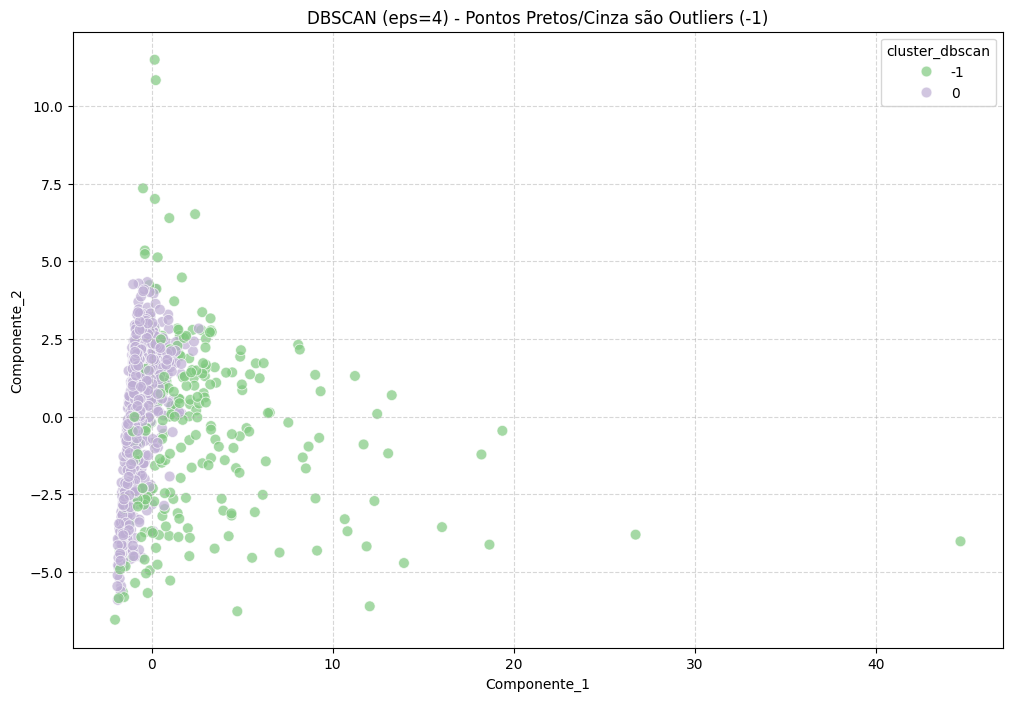

In [173]:
from sklearn.cluster import DBSCAN
import numpy as np

print("="*60)
print(" EXECUTANDO DBSCAN: IDENTIFICAÇÃO DE DENSIDADE E RUÍDO")
print("="*60)

# 1. Configuração do Modelo
# Se o seu gráfico K-Distance subiu bruscamente em 4, use eps=4.
eps_valor = 4
min_samples_valor = 15

dbscan = DBSCAN(eps=eps_valor, min_samples=min_samples_valor)
labels_dbscan = dbscan.fit_predict(X_scaled)

# 2. Salvando os resultados
df_ml['cluster_dbscan'] = labels_dbscan
df_visualizacao['cluster_dbscan'] = labels_dbscan

# 3. Relatório de Descobertas
n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_ruido = list(labels_dbscan).count(-1)

print(f"Número de clusters encontrados: {n_clusters}")
print(f"Municípios classificados como RUÍDO (Outliers): {n_ruido}")
print(f"Percentual de ruído: {(n_ruido/len(df_ml))*100:.2f}%")
print("-" * 60)

# 4. Visualização Gráfica
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Componente_1',
    y='Componente_2',
    hue='cluster_dbscan',
    data=df_visualizacao,
    palette='Accent',
    s=60,
    alpha=0.7
)
plt.title(f'DBSCAN (eps={eps_valor}) - Pontos Pretos/Cinza são Outliers (-1)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
print("="*60)

Apenas um cluste. Devemos investigar quem sao os 213 municipios que o dbscan jogou fora

In [164]:
print("="*60)
print(" INVESTIGANDO OS 213 OUTLIERS (O QUE HÁ DE ESTRANHO NELES?)")
print("="*60)

# Filtra apenas os municípios que o DBSCAN classificou como ruído (-1)
df_ruido = df_ml[df_ml['cluster_dbscan'] == -1].copy()

# Vamos ver as médias desse grupo de "estranhos" comparado com a média nacional
media_nacional = df_ml.select_dtypes(include=[np.number]).mean()
media_ruido = df_ruido.select_dtypes(include=[np.number]).mean()

comparativo = pd.DataFrame({
    'Média Nacional': media_nacional,
    'Média dos Outliers': media_ruido
}).loc[['taxa_incidencia_100k', 'prop_hospitalizado_%', 'indice_sazonalidade_mensal']]

display(comparativo)

print("\nTOP 10 MUNICÍPIOS MAIS 'ANÔMALOS':")
display(df_ruido[['nome_municipio', 'UF_Residencia', 'taxa_incidencia_100k', 'indice_sazonalidade_mensal']].sort_values(by='taxa_incidencia_100k', ascending=False).head(10))
print("="*60)

 INVESTIGANDO OS 213 OUTLIERS (O QUE HÁ DE ESTRANHO NELES?)


,Média Nacional,Média dos Outliers
taxa_incidencia_100k,1138.058423,899.414311
prop_hospitalizado_%,9.323768,21.499439
indice_sazonalidade_mensal,0.331880,0.332109



TOP 10 MUNICÍPIOS MAIS 'ANÔMALOS':


,nome_municipio,UF_Residencia,taxa_incidencia_100k,indice_sazonalidade_mensal
1656,Porecatu (PR),41,18263.936683,0.361778
1249,Conchas (SP),35,14318.539916,0.460895
1605,Laranjal (PR),41,13000.000000,0.392236
1507,Turmalina (SP),35,9706.411025,0.508571
1436,Pracinha (SP),35,8650.116369,0.515695
1381,Onda Verde (SP),35,7713.267659,0.274151
1440,Presidente Prudente (SP),35,7422.408139,0.362106
1168,Alfredo Marcondes (SP),35,5849.268841,0.461207
1300,Indaiatuba (SP),35,5817.836308,0.441033
2070,Montividiu (GO),52,5550.674866,0.239946


#Explicando o modelo

 XAI FINAL: ANALISANDO GATILHOS REAIS (SEM REDUNDÂNCIAS)


/tmp/ipython-input-311/1931750687.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia (%)', y='Atributo', data=df_importancia.head(12), palette='viridis')


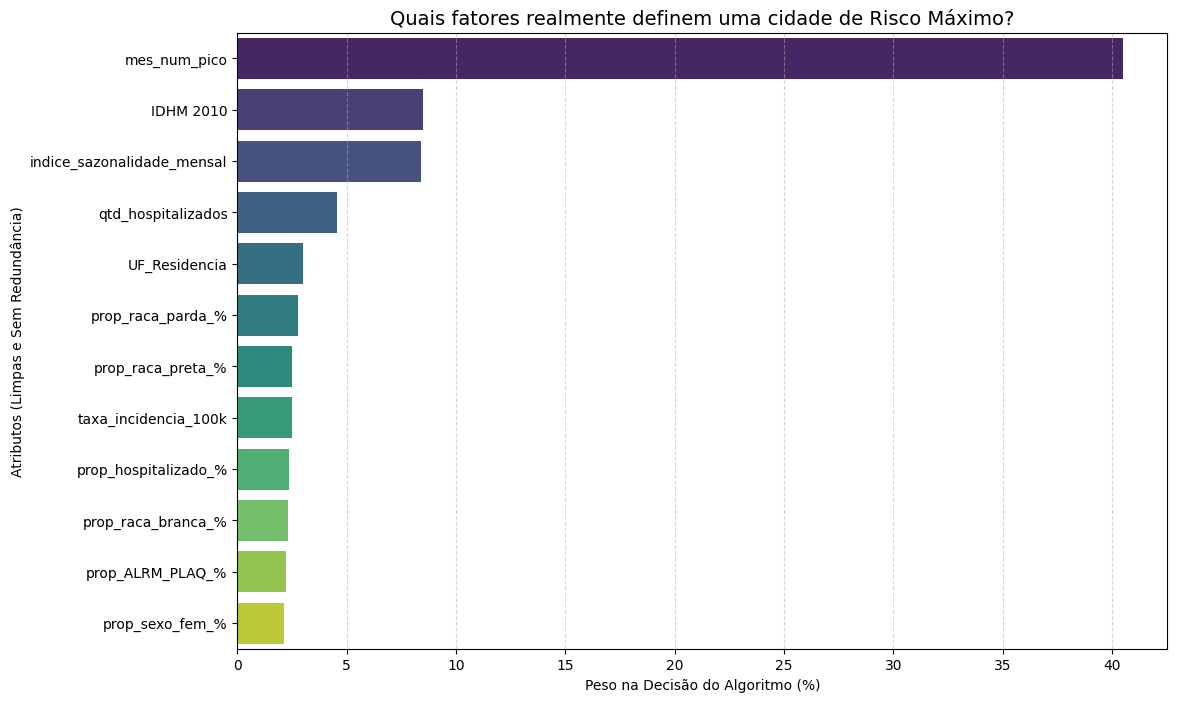


--- DIAGNÓSTICO DO MODELO ---
mes_num_pico: Responsável por 40.50% da classificação de risco.
IDHM 2010: Responsável por 8.48% da classificação de risco.
indice_sazonalidade_mensal: Responsável por 8.41% da classificação de risco.
qtd_hospitalizados: Responsável por 4.57% da classificação de risco.
UF_Residencia: Responsável por 3.00% da classificação de risco.


In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

print("="*60)
print(" XAI FINAL: ANALISANDO GATILHOS REAIS (SEM REDUNDÂNCIAS)")
print("="*60)

# 1. Definindo o Alvo (Target)
cluster_critico_id = df_ml.groupby('cluster_kmeans')['taxa_incidencia_100k'].mean().idxmax()
y_alvo = (df_ml['cluster_kmeans'] == cluster_critico_id).astype(int)

# 2. LIMPEZA PROFUNDA DE ATRIBUTOS
# Pegamos apenas colunas numéricas
X_rf = df_ml.select_dtypes(include=[np.number]).copy()

# A. Removemos duplicatas de merge (_x, _y)
X_rf = X_rf.loc[:, ~X_rf.columns.str.endswith('_x')]
X_rf = X_rf.loc[:, ~X_rf.columns.str.endswith('_y')]

# B. Removemos atributos irrelevantes ou redundantes (conforme solicitado)
# Retiramos 'meses_com_dengue' e 'indice_persistencia_mensal' por serem constantes/redundantes
colunas_para_excluir = [
    'cluster_kmeans', 'cluster_dbscan', 'cluster', # Gabaritos
    'populacao', 'total_casos_dengue', 'casos_pico_mes', # Valores absolutos
    'meses_com_dengue', 'indice_persistencia_mensal', # Redundâncias temporais
    'ID_MN_RESI' # Identificadores
]
X_rf = X_rf.drop(columns=[c for c in colunas_para_excluir if c in X_rf.columns], errors='ignore')

# 3. GARANTINDO O MÊS DO PICO COMO NÚMERO (1-12)
# Se o mês não estiver em X_rf, tentamos converter do df_ml
if 'mes_num_pico' not in X_rf.columns and 'Mês_do_Pico' in df_ml.columns:
    X_rf['mes_num_pico'] = pd.to_datetime(df_ml['Mês_do_Pico']).dt.month

# 4. Treinando o Modelo de Explicação
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_rf, y_alvo)

# 5. Ranking de Importância
df_importancia = pd.DataFrame({
    'Atributo': X_rf.columns,
    'Importancia (%)': rf_model.feature_importances_ * 100
}).sort_values(by='Importancia (%)', ascending=False)

# 6. Gráfico de Resultado
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia (%)', y='Atributo', data=df_importancia.head(12), palette='viridis')
plt.title('Quais fatores realmente definem uma cidade de Risco Máximo?', fontsize=14)
plt.xlabel('Peso na Decisão do Algoritmo (%)')
plt.ylabel('Atributos (Limpas e Sem Redundância)')
plt.grid(True, linestyle='--', alpha=0.5, axis='x')
plt.show()

print("\n--- DIAGNÓSTICO DO MODELO ---")
for i, row in df_importancia.head(5).iterrows():
    print(f"{row['Atributo']}: Responsável por {row['Importancia (%)']:.2f}% da classificação de risco.")
print("="*60)